# Warehouse Outbound Process - Three-Formalism Stutter Equivalence

This notebook verifies stutter equivalence of a complex **6-station warehouse outbound process** modeled in three formalisms:
- **Event Graph (EG)**: Next-Event Time-Advance (Schruben 1983)
- **Activity Cycle Diagram (ACD)**: Activity Scanning (Tocher 1960)
- **DEVS**: Abstract Simulator (Zeigler et al. 2018)

## Warehouse Process Overview

The warehouse has 6 service stations:
- **S1**: Pick Zone A (4 servers)
- **S2**: Pick Zone B (2 servers)
- **S3**: Label (3 servers)
- **S4**: Scan (1 server)
- **S5**: Pack (3 servers)
- **S6**: Release (2 servers)

Jobs enter through 4 creation streams (2 for Zone A, 2 for Zone B), then flow through Label, Scan, Pack, Release.

## Observation Level W

We verify equivalence using **21 atomic propositions** tracking busy servers at all 6 stations:
- S1: s1_busy_eq_{0,1,2,3,4} (5 props)
- S2: s2_busy_eq_{0,1,2} (3 props)
- S3: s3_busy_eq_{0,1,2,3} (4 props)
- S4: s4_busy_eq_{0,1} (2 props)
- S5: s5_busy_eq_{0,1,2,3} (4 props)
- S6: s6_busy_eq_{0,1,2} (3 props)

In [ ]:
# Install simasm
!pip install simasm==0.5.3

import simasm
print(f"SimASM version: {simasm.__version__}")

SimASM version: 0.5.3


## 1. Define Warehouse Event Graph JSON

In [2]:
# Warehouse Event Graph JSON specification
warehouse_eg_json = {
  "model_name": "warehouse_eg",
  "description": "Warehouse Outbound Process using Event Graph formalism (Schruben 1983)",

  "state_variables": {
    "Q1": {"type": "Nat", "initial": 0, "description": "Pick Zone A queue"},
    "Q2": {"type": "Nat", "initial": 0, "description": "Pick Zone B queue"},
    "Q3": {"type": "Nat", "initial": 0, "description": "Labelling queue"},
    "Q4": {"type": "Nat", "initial": 0, "description": "Scanning queue"},
    "Q5": {"type": "Nat", "initial": 0, "description": "Packing queue"},
    "Q6": {"type": "Nat", "initial": 0, "description": "Release queue"},
    "S1": {"type": "Nat", "initial": 4, "description": "Pick Zone A available servers"},
    "S2": {"type": "Nat", "initial": 2, "description": "Pick Zone B available servers"},
    "S3": {"type": "Nat", "initial": 3, "description": "Labelling available servers"},
    "S4": {"type": "Nat", "initial": 1, "description": "Scanning available servers"},
    "S5": {"type": "Nat", "initial": 3, "description": "Packing available servers"},
    "S6": {"type": "Nat", "initial": 2, "description": "Release available servers"},
    "departures": {"type": "Nat", "initial": 0, "description": "Total completed jobs"}
  },

  "parameters": {
    "Q1_max": {"type": "Nat", "value": 30}, "Q2_max": {"type": "Nat", "value": 20},
    "Q3_max": {"type": "Nat", "value": 50}, "Q4_max": {"type": "Nat", "value": 20},
    "Q5_max": {"type": "Nat", "value": 30}, "Q6_max": {"type": "Nat", "value": 20},
    "S1_capacity": {"type": "Nat", "value": 4}, "S2_capacity": {"type": "Nat", "value": 2},
    "S3_capacity": {"type": "Nat", "value": 3}, "S4_capacity": {"type": "Nat", "value": 1},
    "S5_capacity": {"type": "Nat", "value": 3}, "S6_capacity": {"type": "Nat", "value": 2},
    "iat_c1_mean": {"type": "Real", "value": 325.5}, "iat_c2_mean": {"type": "Real", "value": 527.6},
    "iat_c3_mean": {"type": "Real", "value": 226.1}, "iat_c4_mean": {"type": "Real", "value": 985.6},
    "ist_s1_mean": {"type": "Real", "value": 78.4}, "ist_s2_mean": {"type": "Real", "value": 76.2},
    "ist_s3_mean": {"type": "Real", "value": 288.8}, "ist_s4_mean": {"type": "Real", "value": 31.2},
    "ist_s5_mean": {"type": "Real", "value": 66.8}, "ist_s6_mean": {"type": "Real", "value": 1.0},
    "sim_end_time": {"type": "Real", "value": 10000.0}
  },

  "random_streams": {
    "T_c1": {"distribution": "exponential", "params": {"mean": "iat_c1_mean"}, "stream_name": "creation_za1"},
    "T_c2": {"distribution": "exponential", "params": {"mean": "iat_c2_mean"}, "stream_name": "creation_za2"},
    "T_c3": {"distribution": "exponential", "params": {"mean": "iat_c3_mean"}, "stream_name": "creation_zb1"},
    "T_c4": {"distribution": "exponential", "params": {"mean": "iat_c4_mean"}, "stream_name": "creation_zb2"},
    "T_s1": {"distribution": "exponential", "params": {"mean": "ist_s1_mean"}, "stream_name": "service_pick_a"},
    "T_s2": {"distribution": "exponential", "params": {"mean": "ist_s2_mean"}, "stream_name": "service_pick_b"},
    "T_s3": {"distribution": "exponential", "params": {"mean": "ist_s3_mean"}, "stream_name": "service_label"},
    "T_s4": {"distribution": "exponential", "params": {"mean": "ist_s4_mean"}, "stream_name": "service_scan"},
    "T_s5": {"distribution": "exponential", "params": {"mean": "ist_s5_mean"}, "stream_name": "service_pack"},
    "T_s6": {"distribution": "exponential", "params": {"mean": "ist_s6_mean"}, "stream_name": "service_release"}
  },

  "vertices": [
    {"name": "CreateZA1", "state_change": "", "description": "Create Zone A Type 1 job"},
    {"name": "CreateZA2", "state_change": "", "description": "Create Zone A Type 2 job"},
    {"name": "CreateZB1", "state_change": "", "description": "Create Zone B Type 1 job"},
    {"name": "CreateZB2", "state_change": "", "description": "Create Zone B Type 2 job"},
    {"name": "AttemptQueueZAT1", "state_change": "", "description": "Attempt Queue Zone A Type 1"},
    {"name": "AttemptQueueZAT2", "state_change": "", "description": "Attempt Queue Zone A Type 2"},
    {"name": "AttemptQueueZBT1", "state_change": "", "description": "Attempt Queue Zone B Type 1"},
    {"name": "AttemptQueueZBT2", "state_change": "", "description": "Attempt Queue Zone B Type 2"},
    {"name": "QueueQ1", "state_change": "Q1 := Q1 + 1", "description": "Queue in Pick Zone A"},
    {"name": "QueueQ2", "state_change": "Q2 := Q2 + 1", "description": "Queue in Pick Zone B"},
    {"name": "AttemptPickA", "state_change": "", "description": "Attempt Pick Zone A"},
    {"name": "AttemptPickB", "state_change": "", "description": "Attempt Pick Zone B"},
    {"name": "StartPickA", "state_change": "Q1 := Q1 - 1; S1 := S1 - 1", "description": "Start Pick A"},
    {"name": "StartPickB", "state_change": "Q2 := Q2 - 1; S2 := S2 - 1", "description": "Start Pick B"},
    {"name": "FinishPickA", "state_change": "S1 := S1 + 1", "description": "Finish Pick A"},
    {"name": "FinishPickB", "state_change": "S2 := S2 + 1", "description": "Finish Pick B"},
    {"name": "AttemptQueueQ3", "state_change": "", "description": "Attempt Queue after Picking"},
    {"name": "QueueQ3", "state_change": "Q3 := Q3 + 1", "description": "Queue after Picking"},
    {"name": "AttemptLabel", "state_change": "", "description": "Attempt Label"},
    {"name": "StartLabel", "state_change": "Q3 := Q3 - 1; S3 := S3 - 1", "description": "Start Label"},
    {"name": "FinishLabel", "state_change": "S3 := S3 + 1", "description": "Finish Label"},
    {"name": "AttemptQueueQ4", "state_change": "", "description": "Attempt Queue after Labelling"},
    {"name": "QueueQ4", "state_change": "Q4 := Q4 + 1", "description": "Queue after Labelling"},
    {"name": "AttemptScan", "state_change": "", "description": "Attempt Scan"},
    {"name": "StartScan", "state_change": "Q4 := Q4 - 1; S4 := S4 - 1", "description": "Start Scan"},
    {"name": "FinishScan", "state_change": "S4 := S4 + 1", "description": "Finish Scan"},
    {"name": "AttemptQueueQ5", "state_change": "", "description": "Attempt Queue after Scanning"},
    {"name": "QueueQ5", "state_change": "Q5 := Q5 + 1", "description": "Queue after Scanning"},
    {"name": "AttemptPack", "state_change": "", "description": "Attempt Pack"},
    {"name": "StartPack", "state_change": "Q5 := Q5 - 1; S5 := S5 - 1", "description": "Start Pack"},
    {"name": "FinishPack", "state_change": "S5 := S5 + 1", "description": "Finish Pack"},
    {"name": "AttemptQueueQ6", "state_change": "", "description": "Attempt Queue after Packing"},
    {"name": "QueueQ6", "state_change": "Q6 := Q6 + 1", "description": "Queue after Packing"},
    {"name": "AttemptRelease", "state_change": "", "description": "Attempt Release"},
    {"name": "StartRelease", "state_change": "Q6 := Q6 - 1; S6 := S6 - 1", "description": "Start Release"},
    {"name": "FinishRelease", "state_change": "S6 := S6 + 1; departures := departures + 1", "description": "Finish Release"}
  ],

  "scheduling_edges": [
    # Creation streams - reschedule self and attempt to queue
    {"from": "CreateZA1", "to": "CreateZA1", "delay": "T_c1", "condition": "true", "priority": 1},
    {"from": "CreateZA1", "to": "AttemptQueueZAT1", "delay": 0, "condition": "true", "priority": 1},
    {"from": "CreateZA2", "to": "CreateZA2", "delay": "T_c2", "condition": "true", "priority": 2},
    {"from": "CreateZA2", "to": "AttemptQueueZAT2", "delay": 0, "condition": "true", "priority": 2},
    {"from": "CreateZB1", "to": "CreateZB1", "delay": "T_c3", "condition": "true", "priority": 3},
    {"from": "CreateZB1", "to": "AttemptQueueZBT1", "delay": 0, "condition": "true", "priority": 3},
    {"from": "CreateZB2", "to": "CreateZB2", "delay": "T_c4", "condition": "true", "priority": 4},
    {"from": "CreateZB2", "to": "AttemptQueueZBT2", "delay": 0, "condition": "true", "priority": 4},
    # Queue admission control
    {"from": "AttemptQueueZAT1", "to": "QueueQ1", "delay": 0, "condition": "Q1 < Q1_max", "priority": 5},
    {"from": "AttemptQueueZAT2", "to": "QueueQ1", "delay": 0, "condition": "Q1 < Q1_max", "priority": 5},
    {"from": "AttemptQueueZBT1", "to": "QueueQ2", "delay": 0, "condition": "Q2 < Q2_max", "priority": 5},
    {"from": "AttemptQueueZBT2", "to": "QueueQ2", "delay": 0, "condition": "Q2 < Q2_max", "priority": 5},
    # After queueing, attempt to start service
    {"from": "QueueQ1", "to": "AttemptPickA", "delay": 0, "condition": "true", "priority": 6},
    {"from": "QueueQ2", "to": "AttemptPickB", "delay": 0, "condition": "true", "priority": 6},
    # Pick Zone A service
    {"from": "AttemptPickA", "to": "StartPickA", "delay": 0, "condition": "S1 > 0 and Q1 > 0", "priority": 7},
    {"from": "StartPickA", "to": "FinishPickA", "delay": "T_s1", "condition": "true", "priority": 5},
    {"from": "FinishPickA", "to": "AttemptQueueQ3", "delay": 0, "condition": "true", "priority": 7},
    {"from": "FinishPickA", "to": "AttemptPickA", "delay": 0, "condition": "true", "priority": 7},
    # Pick Zone B service
    {"from": "AttemptPickB", "to": "StartPickB", "delay": 0, "condition": "S2 > 0 and Q2 > 0", "priority": 7},
    {"from": "StartPickB", "to": "FinishPickB", "delay": "T_s2", "condition": "true", "priority": 6},
    {"from": "FinishPickB", "to": "AttemptQueueQ3", "delay": 0, "condition": "true", "priority": 6},
    {"from": "FinishPickB", "to": "AttemptPickB", "delay": 0, "condition": "true", "priority": 6},
    # Label queue and service
    {"from": "AttemptQueueQ3", "to": "QueueQ3", "delay": 0, "condition": "Q3 < Q3_max", "priority": 8},
    {"from": "QueueQ3", "to": "AttemptLabel", "delay": 0, "condition": "true", "priority": 9},
    {"from": "AttemptLabel", "to": "StartLabel", "delay": 0, "condition": "S3 > 0 and Q3 > 0", "priority": 7},
    {"from": "StartLabel", "to": "FinishLabel", "delay": "T_s3", "condition": "true", "priority": 7},
    {"from": "FinishLabel", "to": "AttemptQueueQ4", "delay": 0, "condition": "true", "priority": 8},
    {"from": "FinishLabel", "to": "AttemptLabel", "delay": 0, "condition": "true", "priority": 7},
    # Scan queue and service
    {"from": "AttemptQueueQ4", "to": "QueueQ4", "delay": 0, "condition": "Q4 < Q4_max", "priority": 9},
    {"from": "QueueQ4", "to": "AttemptScan", "delay": 0, "condition": "true", "priority": 10},
    {"from": "AttemptScan", "to": "StartScan", "delay": 0, "condition": "S4 > 0 and Q4 > 0", "priority": 8},
    {"from": "StartScan", "to": "FinishScan", "delay": "T_s4", "condition": "true", "priority": 8},
    {"from": "FinishScan", "to": "AttemptQueueQ5", "delay": 0, "condition": "true", "priority": 9},
    {"from": "FinishScan", "to": "AttemptScan", "delay": 0, "condition": "true", "priority": 8},
    # Pack queue and service
    {"from": "AttemptQueueQ5", "to": "QueueQ5", "delay": 0, "condition": "Q5 < Q5_max", "priority": 10},
    {"from": "QueueQ5", "to": "AttemptPack", "delay": 0, "condition": "true", "priority": 9},
    {"from": "AttemptPack", "to": "StartPack", "delay": 0, "condition": "S5 > 0 and Q5 > 0", "priority": 9},
    {"from": "StartPack", "to": "FinishPack", "delay": "T_s5", "condition": "true", "priority": 9},
    {"from": "FinishPack", "to": "AttemptQueueQ6", "delay": 0, "condition": "true", "priority": 10},
    {"from": "FinishPack", "to": "AttemptPack", "delay": 0, "condition": "true", "priority": 9},
    # Release queue and service
    {"from": "AttemptQueueQ6", "to": "QueueQ6", "delay": 0, "condition": "Q6 < Q6_max", "priority": 10},
    {"from": "QueueQ6", "to": "AttemptRelease", "delay": 0, "condition": "true", "priority": 10},
    {"from": "AttemptRelease", "to": "StartRelease", "delay": 0, "condition": "S6 > 0 and Q6 > 0", "priority": 10},
    {"from": "StartRelease", "to": "FinishRelease", "delay": "T_s6", "condition": "true", "priority": 10},
    {"from": "FinishRelease", "to": "AttemptRelease", "delay": 0, "condition": "true", "priority": 10}
  ],

  "cancelling_edges": [],

  "initial_events": [
    {"event": "CreateZA1", "time": "T_c1"},
    {"event": "CreateZA2", "time": "T_c2"},
    {"event": "CreateZB1", "time": "T_c3"},
    {"event": "CreateZB2", "time": "T_c4"}
  ],

  "stopping_condition": "sim_clocktime >= sim_end_time",

  "observables": {
    "get_S1_busy": {"expression": "S1_capacity - S1", "return_type": "Nat"},
    "get_S2_busy": {"expression": "S2_capacity - S2", "return_type": "Nat"},
    "get_S3_busy": {"expression": "S3_capacity - S3", "return_type": "Nat"},
    "get_S4_busy": {"expression": "S4_capacity - S4", "return_type": "Nat"},
    "get_S5_busy": {"expression": "S5_capacity - S5", "return_type": "Nat"},
    "get_S6_busy": {"expression": "S6_capacity - S6", "return_type": "Nat"}
  }
}

print(f"Warehouse EG JSON defined with {len(warehouse_eg_json['vertices'])} vertices")

# Save JSON to file for the converter
import json
with open("warehouse_eg.json", "w") as f:
    json.dump(warehouse_eg_json, f, indent=2)
print("Saved warehouse_eg.json")

Warehouse EG JSON defined with 36 vertices
Saved warehouse_eg.json


## 2. Define Warehouse ACD JSON

In [3]:
# Warehouse ACD JSON specification
warehouse_acd_json = {
  "model_name": "warehouse_acd",
  "description": "Warehouse Outbound Process using Activity Cycle Diagram formalism",

  "parameters": {
    "Q1_max": {"type": "Nat", "value": 30}, "Q2_max": {"type": "Nat", "value": 20},
    "Q3_max": {"type": "Nat", "value": 50}, "Q4_max": {"type": "Nat", "value": 20},
    "Q5_max": {"type": "Nat", "value": 30}, "Q6_max": {"type": "Nat", "value": 20},
    "S1_capacity": {"type": "Nat", "value": 4}, "S2_capacity": {"type": "Nat", "value": 2},
    "S3_capacity": {"type": "Nat", "value": 3}, "S4_capacity": {"type": "Nat", "value": 1},
    "S5_capacity": {"type": "Nat", "value": 3}, "S6_capacity": {"type": "Nat", "value": 2},
    "iat_c1_mean": {"type": "Real", "value": 325.5}, "iat_c2_mean": {"type": "Real", "value": 527.6},
    "iat_c3_mean": {"type": "Real", "value": 226.1}, "iat_c4_mean": {"type": "Real", "value": 985.6},
    "ist_s1_mean": {"type": "Real", "value": 78.4}, "ist_s2_mean": {"type": "Real", "value": 76.2},
    "ist_s3_mean": {"type": "Real", "value": 288.8}, "ist_s4_mean": {"type": "Real", "value": 31.2},
    "ist_s5_mean": {"type": "Real", "value": 66.8}, "ist_s6_mean": {"type": "Real", "value": 1.0},
    "sim_end_time": {"type": "Real", "value": 10000.0}
  },

  "token_types": {
    "Job": {
      "parent": "Token",
      "attributes": {"arrival_time": "Real", "service_start_time": "Real", "job_type": "Nat"},
      "description": "Customer job token"
    },
    "Resource": {"parent": "Token", "description": "Reusable resource token"}
  },

  "queues": {
    "C1": {"initial_marking": 1, "token_type": "Resource", "is_resource": True, "description": "Zone A Type 1 creator"},
    "C2": {"initial_marking": 1, "token_type": "Resource", "is_resource": True, "description": "Zone A Type 2 creator"},
    "C3": {"initial_marking": 1, "token_type": "Resource", "is_resource": True, "description": "Zone B Type 1 creator"},
    "C4": {"initial_marking": 1, "token_type": "Resource", "is_resource": True, "description": "Zone B Type 2 creator"},
    "Q1": {"initial_marking": 0, "token_type": "Job", "is_resource": False, "description": "Pick Zone A queue"},
    "Q2": {"initial_marking": 0, "token_type": "Job", "is_resource": False, "description": "Pick Zone B queue"},
    "Q3": {"initial_marking": 0, "token_type": "Job", "is_resource": False, "description": "Labelling queue"},
    "Q4": {"initial_marking": 0, "token_type": "Job", "is_resource": False, "description": "Scanning queue"},
    "Q5": {"initial_marking": 0, "token_type": "Job", "is_resource": False, "description": "Packing queue"},
    "Q6": {"initial_marking": 0, "token_type": "Job", "is_resource": False, "description": "Release queue"},
    "S1": {"initial_marking": 4, "token_type": "Resource", "is_resource": True, "description": "Pick Zone A servers"},
    "S2": {"initial_marking": 2, "token_type": "Resource", "is_resource": True, "description": "Pick Zone B servers"},
    "S3": {"initial_marking": 3, "token_type": "Resource", "is_resource": True, "description": "Labelling servers"},
    "S4": {"initial_marking": 1, "token_type": "Resource", "is_resource": True, "description": "Scanning servers"},
    "S5": {"initial_marking": 3, "token_type": "Resource", "is_resource": True, "description": "Packing servers"},
    "S6": {"initial_marking": 2, "token_type": "Resource", "is_resource": True, "description": "Release servers"},
    "Jobs": {"initial_marking": 0, "token_type": "Job", "is_resource": False, "description": "Completed jobs"}
  },

  "activities": [
    {
      "name": "CreateZA1", "priority": 1, "description": "Create Zone A Type 1 job",
      "at_begin": {"condition": "marking(C1) >= 1", "action": "C1--", "bind": ["creator_token:C1"]},
      "bto_event": {"time": "duration_create_za1", "name": "CreatedZA1"},
      "at_end": [
        {"arc": 1, "action": "C1++ <- creator_token", "influences": ["CreateZA1"]},
        {"arc": 2, "action": "Q1++ <- new Job", "influences": ["PickZoneA"], "condition": "marking(Q1) < Q1_max"}
      ]
    },
    {
      "name": "CreateZA2", "priority": 2, "description": "Create Zone A Type 2 job",
      "at_begin": {"condition": "marking(C2) >= 1", "action": "C2--", "bind": ["creator_token:C2"]},
      "bto_event": {"time": "duration_create_za2", "name": "CreatedZA2"},
      "at_end": [
        {"arc": 1, "action": "C2++ <- creator_token", "influences": ["CreateZA2"]},
        {"arc": 2, "action": "Q1++ <- new Job", "influences": ["PickZoneA"], "condition": "marking(Q1) < Q1_max"}
      ]
    },
    {
      "name": "CreateZB1", "priority": 3, "description": "Create Zone B Type 1 job",
      "at_begin": {"condition": "marking(C3) >= 1", "action": "C3--", "bind": ["creator_token:C3"]},
      "bto_event": {"time": "duration_create_zb1", "name": "CreatedZB1"},
      "at_end": [
        {"arc": 1, "action": "C3++ <- creator_token", "influences": ["CreateZB1"]},
        {"arc": 2, "action": "Q2++ <- new Job", "influences": ["PickZoneB"], "condition": "marking(Q2) < Q2_max"}
      ]
    },
    {
      "name": "CreateZB2", "priority": 4, "description": "Create Zone B Type 2 job",
      "at_begin": {"condition": "marking(C4) >= 1", "action": "C4--", "bind": ["creator_token:C4"]},
      "bto_event": {"time": "duration_create_zb2", "name": "CreatedZB2"},
      "at_end": [
        {"arc": 1, "action": "C4++ <- creator_token", "influences": ["CreateZB2"]},
        {"arc": 2, "action": "Q2++ <- new Job", "influences": ["PickZoneB"], "condition": "marking(Q2) < Q2_max"}
      ]
    },
    {
      "name": "PickZoneA", "priority": 5, "description": "Picking Zone A service",
      "at_begin": {"condition": "marking(Q1) >= 1 and marking(S1) >= 1", "action": "S1--; Q1--", "bind": ["server_token:S1", "job_token:Q1"]},
      "bto_event": {"time": "duration_pick_a", "name": "PickedZoneA"},
      "at_end": [
        {"arc": 1, "action": "S1++ <- server_token", "influences": ["PickZoneA"]},
        {"arc": 2, "action": "Q3++ <- job_token", "influences": ["Label"], "condition": "marking(Q3) < Q3_max"}
      ]
    },
    {
      "name": "PickZoneB", "priority": 6, "description": "Picking Zone B service",
      "at_begin": {"condition": "marking(Q2) >= 1 and marking(S2) >= 1", "action": "S2--; Q2--", "bind": ["server_token:S2", "job_token:Q2"]},
      "bto_event": {"time": "duration_pick_b", "name": "PickedZoneB"},
      "at_end": [
        {"arc": 1, "action": "S2++ <- server_token", "influences": ["PickZoneB"]},
        {"arc": 2, "action": "Q3++ <- job_token", "influences": ["Label"], "condition": "marking(Q3) < Q3_max"}
      ]
    },
    {
      "name": "Label", "priority": 7, "description": "Labelling service",
      "at_begin": {"condition": "marking(Q3) >= 1 and marking(S3) >= 1", "action": "S3--; Q3--", "bind": ["server_token:S3", "job_token:Q3"]},
      "bto_event": {"time": "duration_label", "name": "Labelled"},
      "at_end": [
        {"arc": 1, "action": "S3++ <- server_token", "influences": ["Label"]},
        {"arc": 2, "action": "Q4++ <- job_token", "influences": ["Scan"], "condition": "marking(Q4) < Q4_max"}
      ]
    },
    {
      "name": "Scan", "priority": 8, "description": "Scanning service",
      "at_begin": {"condition": "marking(Q4) >= 1 and marking(S4) >= 1", "action": "S4--; Q4--", "bind": ["server_token:S4", "job_token:Q4"]},
      "bto_event": {"time": "duration_scan", "name": "Scanned"},
      "at_end": [
        {"arc": 1, "action": "S4++ <- server_token", "influences": ["Scan"]},
        {"arc": 2, "action": "Q5++ <- job_token", "influences": ["Pack"], "condition": "marking(Q5) < Q5_max"}
      ]
    },
    {
      "name": "Pack", "priority": 9, "description": "Packing service",
      "at_begin": {"condition": "marking(Q5) >= 1 and marking(S5) >= 1", "action": "S5--; Q5--", "bind": ["server_token:S5", "job_token:Q5"]},
      "bto_event": {"time": "duration_pack", "name": "Packed"},
      "at_end": [
        {"arc": 1, "action": "S5++ <- server_token", "influences": ["Pack"]},
        {"arc": 2, "action": "Q6++ <- job_token", "influences": ["Release"], "condition": "marking(Q6) < Q6_max"}
      ]
    },
    {
      "name": "Release", "priority": 10, "description": "Release service",
      "at_begin": {"condition": "marking(Q6) >= 1 and marking(S6) >= 1", "action": "S6--; Q6--", "bind": ["server_token:S6", "job_token:Q6"]},
      "bto_event": {"time": "duration_release", "name": "Released"},
      "at_end": [
        {"arc": 1, "action": "S6++ <- server_token", "influences": ["Release"]},
        {"arc": 2, "action": "Jobs++ <- job_token", "influences": []}
      ]
    }
  ],

  "random_streams": {
    "duration_create_za1": {"distribution": "exponential", "params": {"mean": "iat_c1_mean"}, "stream_name": "creation_za1"},
    "duration_create_za2": {"distribution": "exponential", "params": {"mean": "iat_c2_mean"}, "stream_name": "creation_za2"},
    "duration_create_zb1": {"distribution": "exponential", "params": {"mean": "iat_c3_mean"}, "stream_name": "creation_zb1"},
    "duration_create_zb2": {"distribution": "exponential", "params": {"mean": "iat_c4_mean"}, "stream_name": "creation_zb2"},
    "duration_pick_a": {"distribution": "exponential", "params": {"mean": "ist_s1_mean"}, "stream_name": "service_pick_a"},
    "duration_pick_b": {"distribution": "exponential", "params": {"mean": "ist_s2_mean"}, "stream_name": "service_pick_b"},
    "duration_label": {"distribution": "exponential", "params": {"mean": "ist_s3_mean"}, "stream_name": "service_label"},
    "duration_scan": {"distribution": "exponential", "params": {"mean": "ist_s4_mean"}, "stream_name": "service_scan"},
    "duration_pack": {"distribution": "exponential", "params": {"mean": "ist_s5_mean"}, "stream_name": "service_pack"},
    "duration_release": {"distribution": "exponential", "params": {"mean": "ist_s6_mean"}, "stream_name": "service_release"}
  },

  "observables": {
    "get_S1_busy": {"expression": "S1_capacity - marking(S1)", "description": "Pick Zone A busy servers"},
    "get_S2_busy": {"expression": "S2_capacity - marking(S2)", "description": "Pick Zone B busy servers"},
    "get_S3_busy": {"expression": "S3_capacity - marking(S3)", "description": "Labelling busy servers"},
    "get_S4_busy": {"expression": "S4_capacity - marking(S4)", "description": "Scanning busy servers"},
    "get_S5_busy": {"expression": "S5_capacity - marking(S5)", "description": "Packing busy servers"},
    "get_S6_busy": {"expression": "S6_capacity - marking(S6)", "description": "Release busy servers"}
  }
}

print(f"Warehouse ACD JSON defined with {len(warehouse_acd_json['activities'])} activities")

# Save JSON to file for the converter
import json
with open("warehouse_acd.json", "w") as f:
    json.dump(warehouse_acd_json, f, indent=2)
print("Saved warehouse_acd.json")

Warehouse ACD JSON defined with 10 activities
Saved warehouse_acd.json


## 3. Define Warehouse DEVS JSON (Per-Server Architecture)

In [4]:
# Warehouse DEVS JSON specification (per-server architecture)
warehouse_devs_json = {
  "model_name": "warehouse_devs",
  "description": "6-station warehouse outbound - per-server DEVS for stream-synchronized equivalence",
  "entities": {
    "Job": {
      "name": "Job",
      "parent": "Object",
      "attributes": {
        "arrival_time": "Real",
        "departure_time": "Real"
      }
    }
  },
  "parameters": {
    "Q1_max": {
      "type": "Nat",
      "value": 30,
      "description": "Queue capacity at PickA"
    },
    "Q2_max": {
      "type": "Nat",
      "value": 20,
      "description": "Queue capacity at PickB"
    },
    "Q3_max": {
      "type": "Nat",
      "value": 50,
      "description": "Queue capacity at Label"
    },
    "Q4_max": {
      "type": "Nat",
      "value": 20,
      "description": "Queue capacity at Scan"
    },
    "Q5_max": {
      "type": "Nat",
      "value": 30,
      "description": "Queue capacity at Pack"
    },
    "Q6_max": {
      "type": "Nat",
      "value": 20,
      "description": "Queue capacity at Release"
    },
    "S1_capacity": {
      "type": "Nat",
      "value": 4,
      "description": "Number of servers at PickA"
    },
    "S2_capacity": {
      "type": "Nat",
      "value": 2,
      "description": "Number of servers at PickB"
    },
    "S3_capacity": {
      "type": "Nat",
      "value": 3,
      "description": "Number of servers at Label"
    },
    "S4_capacity": {
      "type": "Nat",
      "value": 1,
      "description": "Number of servers at Scan"
    },
    "S5_capacity": {
      "type": "Nat",
      "value": 3,
      "description": "Number of servers at Pack"
    },
    "S6_capacity": {
      "type": "Nat",
      "value": 2,
      "description": "Number of servers at Release"
    },
    "iat_c1_mean": {
      "type": "Real",
      "value": 325.5,
      "description": "IAT Zone A Type 1"
    },
    "iat_c2_mean": {
      "type": "Real",
      "value": 527.6,
      "description": "IAT Zone A Type 2"
    },
    "iat_c3_mean": {
      "type": "Real",
      "value": 226.1,
      "description": "IAT Zone B Type 1"
    },
    "iat_c4_mean": {
      "type": "Real",
      "value": 985.6,
      "description": "IAT Zone B Type 2"
    },
    "ist_s1_mean": {
      "type": "Real",
      "value": 78.4,
      "description": "Service time PickA"
    },
    "ist_s2_mean": {
      "type": "Real",
      "value": 76.2,
      "description": "Service time PickB"
    },
    "ist_s3_mean": {
      "type": "Real",
      "value": 288.8,
      "description": "Service time Label"
    },
    "ist_s4_mean": {
      "type": "Real",
      "value": 31.2,
      "description": "Service time Scan"
    },
    "ist_s5_mean": {
      "type": "Real",
      "value": 66.8,
      "description": "Service time Pack"
    },
    "ist_s6_mean": {
      "type": "Real",
      "value": 1.0,
      "description": "Service time Release"
    },
    "sim_end_time": {
      "type": "Real",
      "value": 10000.0,
      "description": "Simulation end time"
    }
  },
  "random_streams": {
    "interarrival_za1": {
      "distribution": "exponential",
      "params": {
        "mean": "iat_c1_mean"
      },
      "stream_name": "creation_za1"
    },
    "interarrival_za2": {
      "distribution": "exponential",
      "params": {
        "mean": "iat_c2_mean"
      },
      "stream_name": "creation_za2"
    },
    "interarrival_zb1": {
      "distribution": "exponential",
      "params": {
        "mean": "iat_c3_mean"
      },
      "stream_name": "creation_zb1"
    },
    "interarrival_zb2": {
      "distribution": "exponential",
      "params": {
        "mean": "iat_c4_mean"
      },
      "stream_name": "creation_zb2"
    },
    "service_time_pick_a": {
      "distribution": "exponential",
      "params": {
        "mean": "ist_s1_mean"
      },
      "stream_name": "service_pick_a"
    },
    "service_time_pick_b": {
      "distribution": "exponential",
      "params": {
        "mean": "ist_s2_mean"
      },
      "stream_name": "service_pick_b"
    },
    "service_time_label": {
      "distribution": "exponential",
      "params": {
        "mean": "ist_s3_mean"
      },
      "stream_name": "service_label"
    },
    "service_time_scan": {
      "distribution": "exponential",
      "params": {
        "mean": "ist_s4_mean"
      },
      "stream_name": "service_scan"
    },
    "service_time_pack": {
      "distribution": "exponential",
      "params": {
        "mean": "ist_s5_mean"
      },
      "stream_name": "service_pack"
    },
    "service_time_release": {
      "distribution": "exponential",
      "params": {
        "mean": "ist_s6_mean"
      },
      "stream_name": "service_release"
    }
  },
  "atomic_models": [
    {
      "name": "GenZA1",
      "description": "Zone A Type 1 job generator",
      "inputs": [],
      "outputs": [
        "out"
      ],
      "states": [
        {
          "name": "active",
          "time_advance": "interarrival_za1"
        }
      ],
      "initial_state": "active",
      "state_variables": {
        "job_count": {
          "type": "Nat",
          "initial": 0
        }
      },
      "internal_transitions": [
        {
          "from": "active",
          "to": "active",
          "state_change": "job_count := job_count + 1"
        }
      ],
      "external_transitions": [],
      "output_function": [
        {
          "state": "active",
          "output_port": "out",
          "value": "job"
        }
      ]
    },
    {
      "name": "GenZA2",
      "description": "Zone A Type 2 job generator",
      "inputs": [],
      "outputs": [
        "out"
      ],
      "states": [
        {
          "name": "active",
          "time_advance": "interarrival_za2"
        }
      ],
      "initial_state": "active",
      "state_variables": {
        "job_count": {
          "type": "Nat",
          "initial": 0
        }
      },
      "internal_transitions": [
        {
          "from": "active",
          "to": "active",
          "state_change": "job_count := job_count + 1"
        }
      ],
      "external_transitions": [],
      "output_function": [
        {
          "state": "active",
          "output_port": "out",
          "value": "job"
        }
      ]
    },
    {
      "name": "GenZB1",
      "description": "Zone B Type 1 job generator",
      "inputs": [],
      "outputs": [
        "out"
      ],
      "states": [
        {
          "name": "active",
          "time_advance": "interarrival_zb1"
        }
      ],
      "initial_state": "active",
      "state_variables": {
        "job_count": {
          "type": "Nat",
          "initial": 0
        }
      },
      "internal_transitions": [
        {
          "from": "active",
          "to": "active",
          "state_change": "job_count := job_count + 1"
        }
      ],
      "external_transitions": [],
      "output_function": [
        {
          "state": "active",
          "output_port": "out",
          "value": "job"
        }
      ]
    },
    {
      "name": "GenZB2",
      "description": "Zone B Type 2 job generator",
      "inputs": [],
      "outputs": [
        "out"
      ],
      "states": [
        {
          "name": "active",
          "time_advance": "interarrival_zb2"
        }
      ],
      "initial_state": "active",
      "state_variables": {
        "job_count": {
          "type": "Nat",
          "initial": 0
        }
      },
      "internal_transitions": [
        {
          "from": "active",
          "to": "active",
          "state_change": "job_count := job_count + 1"
        }
      ],
      "external_transitions": [],
      "output_function": [
        {
          "state": "active",
          "output_port": "out",
          "value": "job"
        }
      ]
    },
    {
      "name": "PickA",
      "description": "PickA queue/dispatcher (4 per-server)",
      "inputs": [
        "in",
        "done_1",
        "done_2",
        "done_3",
        "done_4"
      ],
      "outputs": [
        "dispatch_1",
        "dispatch_2",
        "dispatch_3",
        "dispatch_4"
      ],
      "states": [
        {
          "name": "idle",
          "time_advance": "infinity"
        },
        {
          "name": "dispatch_to_1",
          "time_advance": 0
        },
        {
          "name": "dispatch_to_2",
          "time_advance": 0
        },
        {
          "name": "dispatch_to_3",
          "time_advance": 0
        },
        {
          "name": "dispatch_to_4",
          "time_advance": 0
        }
      ],
      "initial_state": "idle",
      "state_variables": {
        "queue_count": {
          "type": "Nat",
          "initial": 0
        },
        "server_count": {
          "type": "Nat",
          "initial": 0
        },
        "srv_1_free": {
          "type": "Nat",
          "initial": 1
        },
        "srv_2_free": {
          "type": "Nat",
          "initial": 1
        },
        "srv_3_free": {
          "type": "Nat",
          "initial": 1
        },
        "srv_4_free": {
          "type": "Nat",
          "initial": 1
        }
      },
      "internal_transitions": [
        {
          "from": "dispatch_to_1",
          "to": "dispatch_to_2",
          "condition": "queue_count > 1 and srv_2_free == 1",
          "state_change": "queue_count := queue_count - 1; srv_1_free := 0; server_count := server_count + 1"
        },
        {
          "from": "dispatch_to_1",
          "to": "dispatch_to_3",
          "condition": "queue_count > 1 and srv_2_free == 0 and srv_3_free == 1",
          "state_change": "queue_count := queue_count - 1; srv_1_free := 0; server_count := server_count + 1"
        },
        {
          "from": "dispatch_to_1",
          "to": "dispatch_to_4",
          "condition": "queue_count > 1 and srv_2_free == 0 and srv_3_free == 0 and srv_4_free == 1",
          "state_change": "queue_count := queue_count - 1; srv_1_free := 0; server_count := server_count + 1"
        },
        {
          "from": "dispatch_to_1",
          "to": "idle",
          "condition": "queue_count == 1",
          "state_change": "queue_count := queue_count - 1; srv_1_free := 0; server_count := server_count + 1"
        },
        {
          "from": "dispatch_to_1",
          "to": "idle",
          "condition": "queue_count > 1 and srv_2_free == 0 and srv_3_free == 0 and srv_4_free == 0",
          "state_change": "queue_count := queue_count - 1; srv_1_free := 0; server_count := server_count + 1"
        },
        {
          "from": "dispatch_to_2",
          "to": "dispatch_to_3",
          "condition": "queue_count > 1 and srv_3_free == 1",
          "state_change": "queue_count := queue_count - 1; srv_2_free := 0; server_count := server_count + 1"
        },
        {
          "from": "dispatch_to_2",
          "to": "dispatch_to_4",
          "condition": "queue_count > 1 and srv_3_free == 0 and srv_4_free == 1",
          "state_change": "queue_count := queue_count - 1; srv_2_free := 0; server_count := server_count + 1"
        },
        {
          "from": "dispatch_to_2",
          "to": "idle",
          "condition": "queue_count == 1",
          "state_change": "queue_count := queue_count - 1; srv_2_free := 0; server_count := server_count + 1"
        },
        {
          "from": "dispatch_to_2",
          "to": "idle",
          "condition": "queue_count > 1 and srv_3_free == 0 and srv_4_free == 0",
          "state_change": "queue_count := queue_count - 1; srv_2_free := 0; server_count := server_count + 1"
        },
        {
          "from": "dispatch_to_3",
          "to": "dispatch_to_4",
          "condition": "queue_count > 1 and srv_4_free == 1",
          "state_change": "queue_count := queue_count - 1; srv_3_free := 0; server_count := server_count + 1"
        },
        {
          "from": "dispatch_to_3",
          "to": "idle",
          "condition": "queue_count == 1",
          "state_change": "queue_count := queue_count - 1; srv_3_free := 0; server_count := server_count + 1"
        },
        {
          "from": "dispatch_to_3",
          "to": "idle",
          "condition": "queue_count > 1 and srv_4_free == 0",
          "state_change": "queue_count := queue_count - 1; srv_3_free := 0; server_count := server_count + 1"
        },
        {
          "from": "dispatch_to_4",
          "to": "idle",
          "condition": "queue_count == 1",
          "state_change": "queue_count := queue_count - 1; srv_4_free := 0; server_count := server_count + 1"
        },
        {
          "from": "dispatch_to_4",
          "to": "idle",
          "condition": "queue_count > 1",
          "state_change": "queue_count := queue_count - 1; srv_4_free := 0; server_count := server_count + 1"
        }
      ],
      "external_transitions": [
        {
          "from": "idle",
          "input_port": "in",
          "to": "dispatch_to_1",
          "condition": "srv_1_free == 1",
          "state_change": "queue_count := queue_count + 1"
        },
        {
          "from": "idle",
          "input_port": "in",
          "to": "dispatch_to_2",
          "condition": "srv_1_free == 0 and srv_2_free == 1",
          "state_change": "queue_count := queue_count + 1"
        },
        {
          "from": "idle",
          "input_port": "in",
          "to": "dispatch_to_3",
          "condition": "srv_1_free == 0 and srv_2_free == 0 and srv_3_free == 1",
          "state_change": "queue_count := queue_count + 1"
        },
        {
          "from": "idle",
          "input_port": "in",
          "to": "dispatch_to_4",
          "condition": "srv_1_free == 0 and srv_2_free == 0 and srv_3_free == 0 and srv_4_free == 1",
          "state_change": "queue_count := queue_count + 1"
        },
        {
          "from": "idle",
          "input_port": "in",
          "to": "idle",
          "condition": "srv_1_free == 0 and srv_2_free == 0 and srv_3_free == 0 and srv_4_free == 0",
          "state_change": "queue_count := queue_count + 1"
        },
        {
          "from": "dispatch_to_1",
          "input_port": "in",
          "to": "dispatch_to_1",
          "state_change": "queue_count := queue_count + 1"
        },
        {
          "from": "dispatch_to_2",
          "input_port": "in",
          "to": "dispatch_to_2",
          "state_change": "queue_count := queue_count + 1"
        },
        {
          "from": "dispatch_to_3",
          "input_port": "in",
          "to": "dispatch_to_3",
          "state_change": "queue_count := queue_count + 1"
        },
        {
          "from": "dispatch_to_4",
          "input_port": "in",
          "to": "dispatch_to_4",
          "state_change": "queue_count := queue_count + 1"
        },
        {
          "from": "idle",
          "input_port": "done_1",
          "to": "dispatch_to_1",
          "condition": "queue_count > 0",
          "state_change": "srv_1_free := 1; server_count := server_count - 1"
        },
        {
          "from": "idle",
          "input_port": "done_1",
          "to": "idle",
          "condition": "queue_count == 0",
          "state_change": "srv_1_free := 1; server_count := server_count - 1"
        },
        {
          "from": "idle",
          "input_port": "done_2",
          "to": "dispatch_to_2",
          "condition": "queue_count > 0",
          "state_change": "srv_2_free := 1; server_count := server_count - 1"
        },
        {
          "from": "idle",
          "input_port": "done_2",
          "to": "idle",
          "condition": "queue_count == 0",
          "state_change": "srv_2_free := 1; server_count := server_count - 1"
        },
        {
          "from": "idle",
          "input_port": "done_3",
          "to": "dispatch_to_3",
          "condition": "queue_count > 0",
          "state_change": "srv_3_free := 1; server_count := server_count - 1"
        },
        {
          "from": "idle",
          "input_port": "done_3",
          "to": "idle",
          "condition": "queue_count == 0",
          "state_change": "srv_3_free := 1; server_count := server_count - 1"
        },
        {
          "from": "idle",
          "input_port": "done_4",
          "to": "dispatch_to_4",
          "condition": "queue_count > 0",
          "state_change": "srv_4_free := 1; server_count := server_count - 1"
        },
        {
          "from": "idle",
          "input_port": "done_4",
          "to": "idle",
          "condition": "queue_count == 0",
          "state_change": "srv_4_free := 1; server_count := server_count - 1"
        },
        {
          "from": "dispatch_to_1",
          "input_port": "done_1",
          "to": "dispatch_to_1",
          "state_change": "srv_1_free := 1; server_count := server_count - 1"
        },
        {
          "from": "dispatch_to_1",
          "input_port": "done_2",
          "to": "dispatch_to_1",
          "state_change": "srv_2_free := 1; server_count := server_count - 1"
        },
        {
          "from": "dispatch_to_1",
          "input_port": "done_3",
          "to": "dispatch_to_1",
          "state_change": "srv_3_free := 1; server_count := server_count - 1"
        },
        {
          "from": "dispatch_to_1",
          "input_port": "done_4",
          "to": "dispatch_to_1",
          "state_change": "srv_4_free := 1; server_count := server_count - 1"
        },
        {
          "from": "dispatch_to_2",
          "input_port": "done_1",
          "to": "dispatch_to_2",
          "state_change": "srv_1_free := 1; server_count := server_count - 1"
        },
        {
          "from": "dispatch_to_2",
          "input_port": "done_2",
          "to": "dispatch_to_2",
          "state_change": "srv_2_free := 1; server_count := server_count - 1"
        },
        {
          "from": "dispatch_to_2",
          "input_port": "done_3",
          "to": "dispatch_to_2",
          "state_change": "srv_3_free := 1; server_count := server_count - 1"
        },
        {
          "from": "dispatch_to_2",
          "input_port": "done_4",
          "to": "dispatch_to_2",
          "state_change": "srv_4_free := 1; server_count := server_count - 1"
        },
        {
          "from": "dispatch_to_3",
          "input_port": "done_1",
          "to": "dispatch_to_3",
          "state_change": "srv_1_free := 1; server_count := server_count - 1"
        },
        {
          "from": "dispatch_to_3",
          "input_port": "done_2",
          "to": "dispatch_to_3",
          "state_change": "srv_2_free := 1; server_count := server_count - 1"
        },
        {
          "from": "dispatch_to_3",
          "input_port": "done_3",
          "to": "dispatch_to_3",
          "state_change": "srv_3_free := 1; server_count := server_count - 1"
        },
        {
          "from": "dispatch_to_3",
          "input_port": "done_4",
          "to": "dispatch_to_3",
          "state_change": "srv_4_free := 1; server_count := server_count - 1"
        },
        {
          "from": "dispatch_to_4",
          "input_port": "done_1",
          "to": "dispatch_to_4",
          "state_change": "srv_1_free := 1; server_count := server_count - 1"
        },
        {
          "from": "dispatch_to_4",
          "input_port": "done_2",
          "to": "dispatch_to_4",
          "state_change": "srv_2_free := 1; server_count := server_count - 1"
        },
        {
          "from": "dispatch_to_4",
          "input_port": "done_3",
          "to": "dispatch_to_4",
          "state_change": "srv_3_free := 1; server_count := server_count - 1"
        },
        {
          "from": "dispatch_to_4",
          "input_port": "done_4",
          "to": "dispatch_to_4",
          "state_change": "srv_4_free := 1; server_count := server_count - 1"
        }
      ],
      "output_function": [
        {
          "state": "dispatch_to_1",
          "output_port": "dispatch_1",
          "value": "job"
        },
        {
          "state": "dispatch_to_2",
          "output_port": "dispatch_2",
          "value": "job"
        },
        {
          "state": "dispatch_to_3",
          "output_port": "dispatch_3",
          "value": "job"
        },
        {
          "state": "dispatch_to_4",
          "output_port": "dispatch_4",
          "value": "job"
        }
      ]
    },
    {
      "name": "PickA_Srv_1",
      "description": "Individual server 1 for PickA",
      "inputs": [
        "in"
      ],
      "outputs": [
        "out"
      ],
      "states": [
        {
          "name": "passive",
          "time_advance": "infinity"
        },
        {
          "name": "busy",
          "time_advance": "service_time_pick_a"
        }
      ],
      "initial_state": "passive",
      "state_variables": {},
      "internal_transitions": [
        {
          "from": "busy",
          "to": "passive"
        }
      ],
      "external_transitions": [
        {
          "from": "passive",
          "input_port": "in",
          "to": "busy"
        }
      ],
      "output_function": [
        {
          "state": "busy",
          "output_port": "out",
          "value": "job"
        }
      ]
    },
    {
      "name": "PickA_Srv_2",
      "description": "Individual server 2 for PickA",
      "inputs": [
        "in"
      ],
      "outputs": [
        "out"
      ],
      "states": [
        {
          "name": "passive",
          "time_advance": "infinity"
        },
        {
          "name": "busy",
          "time_advance": "service_time_pick_a"
        }
      ],
      "initial_state": "passive",
      "state_variables": {},
      "internal_transitions": [
        {
          "from": "busy",
          "to": "passive"
        }
      ],
      "external_transitions": [
        {
          "from": "passive",
          "input_port": "in",
          "to": "busy"
        }
      ],
      "output_function": [
        {
          "state": "busy",
          "output_port": "out",
          "value": "job"
        }
      ]
    },
    {
      "name": "PickA_Srv_3",
      "description": "Individual server 3 for PickA",
      "inputs": [
        "in"
      ],
      "outputs": [
        "out"
      ],
      "states": [
        {
          "name": "passive",
          "time_advance": "infinity"
        },
        {
          "name": "busy",
          "time_advance": "service_time_pick_a"
        }
      ],
      "initial_state": "passive",
      "state_variables": {},
      "internal_transitions": [
        {
          "from": "busy",
          "to": "passive"
        }
      ],
      "external_transitions": [
        {
          "from": "passive",
          "input_port": "in",
          "to": "busy"
        }
      ],
      "output_function": [
        {
          "state": "busy",
          "output_port": "out",
          "value": "job"
        }
      ]
    },
    {
      "name": "PickA_Srv_4",
      "description": "Individual server 4 for PickA",
      "inputs": [
        "in"
      ],
      "outputs": [
        "out"
      ],
      "states": [
        {
          "name": "passive",
          "time_advance": "infinity"
        },
        {
          "name": "busy",
          "time_advance": "service_time_pick_a"
        }
      ],
      "initial_state": "passive",
      "state_variables": {},
      "internal_transitions": [
        {
          "from": "busy",
          "to": "passive"
        }
      ],
      "external_transitions": [
        {
          "from": "passive",
          "input_port": "in",
          "to": "busy"
        }
      ],
      "output_function": [
        {
          "state": "busy",
          "output_port": "out",
          "value": "job"
        }
      ]
    },
    {
      "name": "PickB",
      "description": "PickB queue/dispatcher (2 per-server)",
      "inputs": [
        "in",
        "done_1",
        "done_2"
      ],
      "outputs": [
        "dispatch_1",
        "dispatch_2"
      ],
      "states": [
        {
          "name": "idle",
          "time_advance": "infinity"
        },
        {
          "name": "dispatch_to_1",
          "time_advance": 0
        },
        {
          "name": "dispatch_to_2",
          "time_advance": 0
        }
      ],
      "initial_state": "idle",
      "state_variables": {
        "queue_count": {
          "type": "Nat",
          "initial": 0
        },
        "server_count": {
          "type": "Nat",
          "initial": 0
        },
        "srv_1_free": {
          "type": "Nat",
          "initial": 1
        },
        "srv_2_free": {
          "type": "Nat",
          "initial": 1
        }
      },
      "internal_transitions": [
        {
          "from": "dispatch_to_1",
          "to": "dispatch_to_2",
          "condition": "queue_count > 1 and srv_2_free == 1",
          "state_change": "queue_count := queue_count - 1; srv_1_free := 0; server_count := server_count + 1"
        },
        {
          "from": "dispatch_to_1",
          "to": "idle",
          "condition": "queue_count == 1",
          "state_change": "queue_count := queue_count - 1; srv_1_free := 0; server_count := server_count + 1"
        },
        {
          "from": "dispatch_to_1",
          "to": "idle",
          "condition": "queue_count > 1 and srv_2_free == 0",
          "state_change": "queue_count := queue_count - 1; srv_1_free := 0; server_count := server_count + 1"
        },
        {
          "from": "dispatch_to_2",
          "to": "idle",
          "condition": "queue_count == 1",
          "state_change": "queue_count := queue_count - 1; srv_2_free := 0; server_count := server_count + 1"
        },
        {
          "from": "dispatch_to_2",
          "to": "idle",
          "condition": "queue_count > 1",
          "state_change": "queue_count := queue_count - 1; srv_2_free := 0; server_count := server_count + 1"
        }
      ],
      "external_transitions": [
        {
          "from": "idle",
          "input_port": "in",
          "to": "dispatch_to_1",
          "condition": "srv_1_free == 1",
          "state_change": "queue_count := queue_count + 1"
        },
        {
          "from": "idle",
          "input_port": "in",
          "to": "dispatch_to_2",
          "condition": "srv_1_free == 0 and srv_2_free == 1",
          "state_change": "queue_count := queue_count + 1"
        },
        {
          "from": "idle",
          "input_port": "in",
          "to": "idle",
          "condition": "srv_1_free == 0 and srv_2_free == 0",
          "state_change": "queue_count := queue_count + 1"
        },
        {
          "from": "dispatch_to_1",
          "input_port": "in",
          "to": "dispatch_to_1",
          "state_change": "queue_count := queue_count + 1"
        },
        {
          "from": "dispatch_to_2",
          "input_port": "in",
          "to": "dispatch_to_2",
          "state_change": "queue_count := queue_count + 1"
        },
        {
          "from": "idle",
          "input_port": "done_1",
          "to": "dispatch_to_1",
          "condition": "queue_count > 0",
          "state_change": "srv_1_free := 1; server_count := server_count - 1"
        },
        {
          "from": "idle",
          "input_port": "done_1",
          "to": "idle",
          "condition": "queue_count == 0",
          "state_change": "srv_1_free := 1; server_count := server_count - 1"
        },
        {
          "from": "idle",
          "input_port": "done_2",
          "to": "dispatch_to_2",
          "condition": "queue_count > 0",
          "state_change": "srv_2_free := 1; server_count := server_count - 1"
        },
        {
          "from": "idle",
          "input_port": "done_2",
          "to": "idle",
          "condition": "queue_count == 0",
          "state_change": "srv_2_free := 1; server_count := server_count - 1"
        },
        {
          "from": "dispatch_to_1",
          "input_port": "done_1",
          "to": "dispatch_to_1",
          "state_change": "srv_1_free := 1; server_count := server_count - 1"
        },
        {
          "from": "dispatch_to_1",
          "input_port": "done_2",
          "to": "dispatch_to_1",
          "state_change": "srv_2_free := 1; server_count := server_count - 1"
        },
        {
          "from": "dispatch_to_2",
          "input_port": "done_1",
          "to": "dispatch_to_2",
          "state_change": "srv_1_free := 1; server_count := server_count - 1"
        },
        {
          "from": "dispatch_to_2",
          "input_port": "done_2",
          "to": "dispatch_to_2",
          "state_change": "srv_2_free := 1; server_count := server_count - 1"
        }
      ],
      "output_function": [
        {
          "state": "dispatch_to_1",
          "output_port": "dispatch_1",
          "value": "job"
        },
        {
          "state": "dispatch_to_2",
          "output_port": "dispatch_2",
          "value": "job"
        }
      ]
    },
    {
      "name": "PickB_Srv_1",
      "description": "Individual server 1 for PickB",
      "inputs": [
        "in"
      ],
      "outputs": [
        "out"
      ],
      "states": [
        {
          "name": "passive",
          "time_advance": "infinity"
        },
        {
          "name": "busy",
          "time_advance": "service_time_pick_b"
        }
      ],
      "initial_state": "passive",
      "state_variables": {},
      "internal_transitions": [
        {
          "from": "busy",
          "to": "passive"
        }
      ],
      "external_transitions": [
        {
          "from": "passive",
          "input_port": "in",
          "to": "busy"
        }
      ],
      "output_function": [
        {
          "state": "busy",
          "output_port": "out",
          "value": "job"
        }
      ]
    },
    {
      "name": "PickB_Srv_2",
      "description": "Individual server 2 for PickB",
      "inputs": [
        "in"
      ],
      "outputs": [
        "out"
      ],
      "states": [
        {
          "name": "passive",
          "time_advance": "infinity"
        },
        {
          "name": "busy",
          "time_advance": "service_time_pick_b"
        }
      ],
      "initial_state": "passive",
      "state_variables": {},
      "internal_transitions": [
        {
          "from": "busy",
          "to": "passive"
        }
      ],
      "external_transitions": [
        {
          "from": "passive",
          "input_port": "in",
          "to": "busy"
        }
      ],
      "output_function": [
        {
          "state": "busy",
          "output_port": "out",
          "value": "job"
        }
      ]
    },
    {
      "name": "Label",
      "description": "Label queue/dispatcher (3 per-server)",
      "inputs": [
        "in",
        "done_1",
        "done_2",
        "done_3"
      ],
      "outputs": [
        "dispatch_1",
        "dispatch_2",
        "dispatch_3"
      ],
      "states": [
        {
          "name": "idle",
          "time_advance": "infinity"
        },
        {
          "name": "dispatch_to_1",
          "time_advance": 0
        },
        {
          "name": "dispatch_to_2",
          "time_advance": 0
        },
        {
          "name": "dispatch_to_3",
          "time_advance": 0
        }
      ],
      "initial_state": "idle",
      "state_variables": {
        "queue_count": {
          "type": "Nat",
          "initial": 0
        },
        "server_count": {
          "type": "Nat",
          "initial": 0
        },
        "srv_1_free": {
          "type": "Nat",
          "initial": 1
        },
        "srv_2_free": {
          "type": "Nat",
          "initial": 1
        },
        "srv_3_free": {
          "type": "Nat",
          "initial": 1
        }
      },
      "internal_transitions": [
        {
          "from": "dispatch_to_1",
          "to": "dispatch_to_2",
          "condition": "queue_count > 1 and srv_2_free == 1",
          "state_change": "queue_count := queue_count - 1; srv_1_free := 0; server_count := server_count + 1"
        },
        {
          "from": "dispatch_to_1",
          "to": "dispatch_to_3",
          "condition": "queue_count > 1 and srv_2_free == 0 and srv_3_free == 1",
          "state_change": "queue_count := queue_count - 1; srv_1_free := 0; server_count := server_count + 1"
        },
        {
          "from": "dispatch_to_1",
          "to": "idle",
          "condition": "queue_count == 1",
          "state_change": "queue_count := queue_count - 1; srv_1_free := 0; server_count := server_count + 1"
        },
        {
          "from": "dispatch_to_1",
          "to": "idle",
          "condition": "queue_count > 1 and srv_2_free == 0 and srv_3_free == 0",
          "state_change": "queue_count := queue_count - 1; srv_1_free := 0; server_count := server_count + 1"
        },
        {
          "from": "dispatch_to_2",
          "to": "dispatch_to_3",
          "condition": "queue_count > 1 and srv_3_free == 1",
          "state_change": "queue_count := queue_count - 1; srv_2_free := 0; server_count := server_count + 1"
        },
        {
          "from": "dispatch_to_2",
          "to": "idle",
          "condition": "queue_count == 1",
          "state_change": "queue_count := queue_count - 1; srv_2_free := 0; server_count := server_count + 1"
        },
        {
          "from": "dispatch_to_2",
          "to": "idle",
          "condition": "queue_count > 1 and srv_3_free == 0",
          "state_change": "queue_count := queue_count - 1; srv_2_free := 0; server_count := server_count + 1"
        },
        {
          "from": "dispatch_to_3",
          "to": "idle",
          "condition": "queue_count == 1",
          "state_change": "queue_count := queue_count - 1; srv_3_free := 0; server_count := server_count + 1"
        },
        {
          "from": "dispatch_to_3",
          "to": "idle",
          "condition": "queue_count > 1",
          "state_change": "queue_count := queue_count - 1; srv_3_free := 0; server_count := server_count + 1"
        }
      ],
      "external_transitions": [
        {
          "from": "idle",
          "input_port": "in",
          "to": "dispatch_to_1",
          "condition": "srv_1_free == 1",
          "state_change": "queue_count := queue_count + 1"
        },
        {
          "from": "idle",
          "input_port": "in",
          "to": "dispatch_to_2",
          "condition": "srv_1_free == 0 and srv_2_free == 1",
          "state_change": "queue_count := queue_count + 1"
        },
        {
          "from": "idle",
          "input_port": "in",
          "to": "dispatch_to_3",
          "condition": "srv_1_free == 0 and srv_2_free == 0 and srv_3_free == 1",
          "state_change": "queue_count := queue_count + 1"
        },
        {
          "from": "idle",
          "input_port": "in",
          "to": "idle",
          "condition": "srv_1_free == 0 and srv_2_free == 0 and srv_3_free == 0",
          "state_change": "queue_count := queue_count + 1"
        },
        {
          "from": "dispatch_to_1",
          "input_port": "in",
          "to": "dispatch_to_1",
          "state_change": "queue_count := queue_count + 1"
        },
        {
          "from": "dispatch_to_2",
          "input_port": "in",
          "to": "dispatch_to_2",
          "state_change": "queue_count := queue_count + 1"
        },
        {
          "from": "dispatch_to_3",
          "input_port": "in",
          "to": "dispatch_to_3",
          "state_change": "queue_count := queue_count + 1"
        },
        {
          "from": "idle",
          "input_port": "done_1",
          "to": "dispatch_to_1",
          "condition": "queue_count > 0",
          "state_change": "srv_1_free := 1; server_count := server_count - 1"
        },
        {
          "from": "idle",
          "input_port": "done_1",
          "to": "idle",
          "condition": "queue_count == 0",
          "state_change": "srv_1_free := 1; server_count := server_count - 1"
        },
        {
          "from": "idle",
          "input_port": "done_2",
          "to": "dispatch_to_2",
          "condition": "queue_count > 0",
          "state_change": "srv_2_free := 1; server_count := server_count - 1"
        },
        {
          "from": "idle",
          "input_port": "done_2",
          "to": "idle",
          "condition": "queue_count == 0",
          "state_change": "srv_2_free := 1; server_count := server_count - 1"
        },
        {
          "from": "idle",
          "input_port": "done_3",
          "to": "dispatch_to_3",
          "condition": "queue_count > 0",
          "state_change": "srv_3_free := 1; server_count := server_count - 1"
        },
        {
          "from": "idle",
          "input_port": "done_3",
          "to": "idle",
          "condition": "queue_count == 0",
          "state_change": "srv_3_free := 1; server_count := server_count - 1"
        },
        {
          "from": "dispatch_to_1",
          "input_port": "done_1",
          "to": "dispatch_to_1",
          "state_change": "srv_1_free := 1; server_count := server_count - 1"
        },
        {
          "from": "dispatch_to_1",
          "input_port": "done_2",
          "to": "dispatch_to_1",
          "state_change": "srv_2_free := 1; server_count := server_count - 1"
        },
        {
          "from": "dispatch_to_1",
          "input_port": "done_3",
          "to": "dispatch_to_1",
          "state_change": "srv_3_free := 1; server_count := server_count - 1"
        },
        {
          "from": "dispatch_to_2",
          "input_port": "done_1",
          "to": "dispatch_to_2",
          "state_change": "srv_1_free := 1; server_count := server_count - 1"
        },
        {
          "from": "dispatch_to_2",
          "input_port": "done_2",
          "to": "dispatch_to_2",
          "state_change": "srv_2_free := 1; server_count := server_count - 1"
        },
        {
          "from": "dispatch_to_2",
          "input_port": "done_3",
          "to": "dispatch_to_2",
          "state_change": "srv_3_free := 1; server_count := server_count - 1"
        },
        {
          "from": "dispatch_to_3",
          "input_port": "done_1",
          "to": "dispatch_to_3",
          "state_change": "srv_1_free := 1; server_count := server_count - 1"
        },
        {
          "from": "dispatch_to_3",
          "input_port": "done_2",
          "to": "dispatch_to_3",
          "state_change": "srv_2_free := 1; server_count := server_count - 1"
        },
        {
          "from": "dispatch_to_3",
          "input_port": "done_3",
          "to": "dispatch_to_3",
          "state_change": "srv_3_free := 1; server_count := server_count - 1"
        }
      ],
      "output_function": [
        {
          "state": "dispatch_to_1",
          "output_port": "dispatch_1",
          "value": "job"
        },
        {
          "state": "dispatch_to_2",
          "output_port": "dispatch_2",
          "value": "job"
        },
        {
          "state": "dispatch_to_3",
          "output_port": "dispatch_3",
          "value": "job"
        }
      ]
    },
    {
      "name": "Label_Srv_1",
      "description": "Individual server 1 for Label",
      "inputs": [
        "in"
      ],
      "outputs": [
        "out"
      ],
      "states": [
        {
          "name": "passive",
          "time_advance": "infinity"
        },
        {
          "name": "busy",
          "time_advance": "service_time_label"
        }
      ],
      "initial_state": "passive",
      "state_variables": {},
      "internal_transitions": [
        {
          "from": "busy",
          "to": "passive"
        }
      ],
      "external_transitions": [
        {
          "from": "passive",
          "input_port": "in",
          "to": "busy"
        }
      ],
      "output_function": [
        {
          "state": "busy",
          "output_port": "out",
          "value": "job"
        }
      ]
    },
    {
      "name": "Label_Srv_2",
      "description": "Individual server 2 for Label",
      "inputs": [
        "in"
      ],
      "outputs": [
        "out"
      ],
      "states": [
        {
          "name": "passive",
          "time_advance": "infinity"
        },
        {
          "name": "busy",
          "time_advance": "service_time_label"
        }
      ],
      "initial_state": "passive",
      "state_variables": {},
      "internal_transitions": [
        {
          "from": "busy",
          "to": "passive"
        }
      ],
      "external_transitions": [
        {
          "from": "passive",
          "input_port": "in",
          "to": "busy"
        }
      ],
      "output_function": [
        {
          "state": "busy",
          "output_port": "out",
          "value": "job"
        }
      ]
    },
    {
      "name": "Label_Srv_3",
      "description": "Individual server 3 for Label",
      "inputs": [
        "in"
      ],
      "outputs": [
        "out"
      ],
      "states": [
        {
          "name": "passive",
          "time_advance": "infinity"
        },
        {
          "name": "busy",
          "time_advance": "service_time_label"
        }
      ],
      "initial_state": "passive",
      "state_variables": {},
      "internal_transitions": [
        {
          "from": "busy",
          "to": "passive"
        }
      ],
      "external_transitions": [
        {
          "from": "passive",
          "input_port": "in",
          "to": "busy"
        }
      ],
      "output_function": [
        {
          "state": "busy",
          "output_port": "out",
          "value": "job"
        }
      ]
    },
    {
      "name": "Scan",
      "description": "Scan queue/dispatcher (1 per-server)",
      "inputs": [
        "in",
        "done_1"
      ],
      "outputs": [
        "dispatch_1"
      ],
      "states": [
        {
          "name": "idle",
          "time_advance": "infinity"
        },
        {
          "name": "dispatch_to_1",
          "time_advance": 0
        }
      ],
      "initial_state": "idle",
      "state_variables": {
        "queue_count": {
          "type": "Nat",
          "initial": 0
        },
        "server_count": {
          "type": "Nat",
          "initial": 0
        },
        "srv_1_free": {
          "type": "Nat",
          "initial": 1
        }
      },
      "internal_transitions": [
        {
          "from": "dispatch_to_1",
          "to": "idle",
          "condition": "queue_count == 1",
          "state_change": "queue_count := queue_count - 1; srv_1_free := 0; server_count := server_count + 1"
        },
        {
          "from": "dispatch_to_1",
          "to": "idle",
          "condition": "queue_count > 1",
          "state_change": "queue_count := queue_count - 1; srv_1_free := 0; server_count := server_count + 1"
        }
      ],
      "external_transitions": [
        {
          "from": "idle",
          "input_port": "in",
          "to": "dispatch_to_1",
          "condition": "srv_1_free == 1",
          "state_change": "queue_count := queue_count + 1"
        },
        {
          "from": "idle",
          "input_port": "in",
          "to": "idle",
          "condition": "srv_1_free == 0",
          "state_change": "queue_count := queue_count + 1"
        },
        {
          "from": "dispatch_to_1",
          "input_port": "in",
          "to": "dispatch_to_1",
          "state_change": "queue_count := queue_count + 1"
        },
        {
          "from": "idle",
          "input_port": "done_1",
          "to": "dispatch_to_1",
          "condition": "queue_count > 0",
          "state_change": "srv_1_free := 1; server_count := server_count - 1"
        },
        {
          "from": "idle",
          "input_port": "done_1",
          "to": "idle",
          "condition": "queue_count == 0",
          "state_change": "srv_1_free := 1; server_count := server_count - 1"
        },
        {
          "from": "dispatch_to_1",
          "input_port": "done_1",
          "to": "dispatch_to_1",
          "state_change": "srv_1_free := 1; server_count := server_count - 1"
        }
      ],
      "output_function": [
        {
          "state": "dispatch_to_1",
          "output_port": "dispatch_1",
          "value": "job"
        }
      ]
    },
    {
      "name": "Scan_Srv_1",
      "description": "Individual server 1 for Scan",
      "inputs": [
        "in"
      ],
      "outputs": [
        "out"
      ],
      "states": [
        {
          "name": "passive",
          "time_advance": "infinity"
        },
        {
          "name": "busy",
          "time_advance": "service_time_scan"
        }
      ],
      "initial_state": "passive",
      "state_variables": {},
      "internal_transitions": [
        {
          "from": "busy",
          "to": "passive"
        }
      ],
      "external_transitions": [
        {
          "from": "passive",
          "input_port": "in",
          "to": "busy"
        }
      ],
      "output_function": [
        {
          "state": "busy",
          "output_port": "out",
          "value": "job"
        }
      ]
    },
    {
      "name": "Pack",
      "description": "Pack queue/dispatcher (3 per-server)",
      "inputs": [
        "in",
        "done_1",
        "done_2",
        "done_3"
      ],
      "outputs": [
        "dispatch_1",
        "dispatch_2",
        "dispatch_3"
      ],
      "states": [
        {
          "name": "idle",
          "time_advance": "infinity"
        },
        {
          "name": "dispatch_to_1",
          "time_advance": 0
        },
        {
          "name": "dispatch_to_2",
          "time_advance": 0
        },
        {
          "name": "dispatch_to_3",
          "time_advance": 0
        }
      ],
      "initial_state": "idle",
      "state_variables": {
        "queue_count": {
          "type": "Nat",
          "initial": 0
        },
        "server_count": {
          "type": "Nat",
          "initial": 0
        },
        "srv_1_free": {
          "type": "Nat",
          "initial": 1
        },
        "srv_2_free": {
          "type": "Nat",
          "initial": 1
        },
        "srv_3_free": {
          "type": "Nat",
          "initial": 1
        }
      },
      "internal_transitions": [
        {
          "from": "dispatch_to_1",
          "to": "dispatch_to_2",
          "condition": "queue_count > 1 and srv_2_free == 1",
          "state_change": "queue_count := queue_count - 1; srv_1_free := 0; server_count := server_count + 1"
        },
        {
          "from": "dispatch_to_1",
          "to": "dispatch_to_3",
          "condition": "queue_count > 1 and srv_2_free == 0 and srv_3_free == 1",
          "state_change": "queue_count := queue_count - 1; srv_1_free := 0; server_count := server_count + 1"
        },
        {
          "from": "dispatch_to_1",
          "to": "idle",
          "condition": "queue_count == 1",
          "state_change": "queue_count := queue_count - 1; srv_1_free := 0; server_count := server_count + 1"
        },
        {
          "from": "dispatch_to_1",
          "to": "idle",
          "condition": "queue_count > 1 and srv_2_free == 0 and srv_3_free == 0",
          "state_change": "queue_count := queue_count - 1; srv_1_free := 0; server_count := server_count + 1"
        },
        {
          "from": "dispatch_to_2",
          "to": "dispatch_to_3",
          "condition": "queue_count > 1 and srv_3_free == 1",
          "state_change": "queue_count := queue_count - 1; srv_2_free := 0; server_count := server_count + 1"
        },
        {
          "from": "dispatch_to_2",
          "to": "idle",
          "condition": "queue_count == 1",
          "state_change": "queue_count := queue_count - 1; srv_2_free := 0; server_count := server_count + 1"
        },
        {
          "from": "dispatch_to_2",
          "to": "idle",
          "condition": "queue_count > 1 and srv_3_free == 0",
          "state_change": "queue_count := queue_count - 1; srv_2_free := 0; server_count := server_count + 1"
        },
        {
          "from": "dispatch_to_3",
          "to": "idle",
          "condition": "queue_count == 1",
          "state_change": "queue_count := queue_count - 1; srv_3_free := 0; server_count := server_count + 1"
        },
        {
          "from": "dispatch_to_3",
          "to": "idle",
          "condition": "queue_count > 1",
          "state_change": "queue_count := queue_count - 1; srv_3_free := 0; server_count := server_count + 1"
        }
      ],
      "external_transitions": [
        {
          "from": "idle",
          "input_port": "in",
          "to": "dispatch_to_1",
          "condition": "srv_1_free == 1",
          "state_change": "queue_count := queue_count + 1"
        },
        {
          "from": "idle",
          "input_port": "in",
          "to": "dispatch_to_2",
          "condition": "srv_1_free == 0 and srv_2_free == 1",
          "state_change": "queue_count := queue_count + 1"
        },
        {
          "from": "idle",
          "input_port": "in",
          "to": "dispatch_to_3",
          "condition": "srv_1_free == 0 and srv_2_free == 0 and srv_3_free == 1",
          "state_change": "queue_count := queue_count + 1"
        },
        {
          "from": "idle",
          "input_port": "in",
          "to": "idle",
          "condition": "srv_1_free == 0 and srv_2_free == 0 and srv_3_free == 0",
          "state_change": "queue_count := queue_count + 1"
        },
        {
          "from": "dispatch_to_1",
          "input_port": "in",
          "to": "dispatch_to_1",
          "state_change": "queue_count := queue_count + 1"
        },
        {
          "from": "dispatch_to_2",
          "input_port": "in",
          "to": "dispatch_to_2",
          "state_change": "queue_count := queue_count + 1"
        },
        {
          "from": "dispatch_to_3",
          "input_port": "in",
          "to": "dispatch_to_3",
          "state_change": "queue_count := queue_count + 1"
        },
        {
          "from": "idle",
          "input_port": "done_1",
          "to": "dispatch_to_1",
          "condition": "queue_count > 0",
          "state_change": "srv_1_free := 1; server_count := server_count - 1"
        },
        {
          "from": "idle",
          "input_port": "done_1",
          "to": "idle",
          "condition": "queue_count == 0",
          "state_change": "srv_1_free := 1; server_count := server_count - 1"
        },
        {
          "from": "idle",
          "input_port": "done_2",
          "to": "dispatch_to_2",
          "condition": "queue_count > 0",
          "state_change": "srv_2_free := 1; server_count := server_count - 1"
        },
        {
          "from": "idle",
          "input_port": "done_2",
          "to": "idle",
          "condition": "queue_count == 0",
          "state_change": "srv_2_free := 1; server_count := server_count - 1"
        },
        {
          "from": "idle",
          "input_port": "done_3",
          "to": "dispatch_to_3",
          "condition": "queue_count > 0",
          "state_change": "srv_3_free := 1; server_count := server_count - 1"
        },
        {
          "from": "idle",
          "input_port": "done_3",
          "to": "idle",
          "condition": "queue_count == 0",
          "state_change": "srv_3_free := 1; server_count := server_count - 1"
        },
        {
          "from": "dispatch_to_1",
          "input_port": "done_1",
          "to": "dispatch_to_1",
          "state_change": "srv_1_free := 1; server_count := server_count - 1"
        },
        {
          "from": "dispatch_to_1",
          "input_port": "done_2",
          "to": "dispatch_to_1",
          "state_change": "srv_2_free := 1; server_count := server_count - 1"
        },
        {
          "from": "dispatch_to_1",
          "input_port": "done_3",
          "to": "dispatch_to_1",
          "state_change": "srv_3_free := 1; server_count := server_count - 1"
        },
        {
          "from": "dispatch_to_2",
          "input_port": "done_1",
          "to": "dispatch_to_2",
          "state_change": "srv_1_free := 1; server_count := server_count - 1"
        },
        {
          "from": "dispatch_to_2",
          "input_port": "done_2",
          "to": "dispatch_to_2",
          "state_change": "srv_2_free := 1; server_count := server_count - 1"
        },
        {
          "from": "dispatch_to_2",
          "input_port": "done_3",
          "to": "dispatch_to_2",
          "state_change": "srv_3_free := 1; server_count := server_count - 1"
        },
        {
          "from": "dispatch_to_3",
          "input_port": "done_1",
          "to": "dispatch_to_3",
          "state_change": "srv_1_free := 1; server_count := server_count - 1"
        },
        {
          "from": "dispatch_to_3",
          "input_port": "done_2",
          "to": "dispatch_to_3",
          "state_change": "srv_2_free := 1; server_count := server_count - 1"
        },
        {
          "from": "dispatch_to_3",
          "input_port": "done_3",
          "to": "dispatch_to_3",
          "state_change": "srv_3_free := 1; server_count := server_count - 1"
        }
      ],
      "output_function": [
        {
          "state": "dispatch_to_1",
          "output_port": "dispatch_1",
          "value": "job"
        },
        {
          "state": "dispatch_to_2",
          "output_port": "dispatch_2",
          "value": "job"
        },
        {
          "state": "dispatch_to_3",
          "output_port": "dispatch_3",
          "value": "job"
        }
      ]
    },
    {
      "name": "Pack_Srv_1",
      "description": "Individual server 1 for Pack",
      "inputs": [
        "in"
      ],
      "outputs": [
        "out"
      ],
      "states": [
        {
          "name": "passive",
          "time_advance": "infinity"
        },
        {
          "name": "busy",
          "time_advance": "service_time_pack"
        }
      ],
      "initial_state": "passive",
      "state_variables": {},
      "internal_transitions": [
        {
          "from": "busy",
          "to": "passive"
        }
      ],
      "external_transitions": [
        {
          "from": "passive",
          "input_port": "in",
          "to": "busy"
        }
      ],
      "output_function": [
        {
          "state": "busy",
          "output_port": "out",
          "value": "job"
        }
      ]
    },
    {
      "name": "Pack_Srv_2",
      "description": "Individual server 2 for Pack",
      "inputs": [
        "in"
      ],
      "outputs": [
        "out"
      ],
      "states": [
        {
          "name": "passive",
          "time_advance": "infinity"
        },
        {
          "name": "busy",
          "time_advance": "service_time_pack"
        }
      ],
      "initial_state": "passive",
      "state_variables": {},
      "internal_transitions": [
        {
          "from": "busy",
          "to": "passive"
        }
      ],
      "external_transitions": [
        {
          "from": "passive",
          "input_port": "in",
          "to": "busy"
        }
      ],
      "output_function": [
        {
          "state": "busy",
          "output_port": "out",
          "value": "job"
        }
      ]
    },
    {
      "name": "Pack_Srv_3",
      "description": "Individual server 3 for Pack",
      "inputs": [
        "in"
      ],
      "outputs": [
        "out"
      ],
      "states": [
        {
          "name": "passive",
          "time_advance": "infinity"
        },
        {
          "name": "busy",
          "time_advance": "service_time_pack"
        }
      ],
      "initial_state": "passive",
      "state_variables": {},
      "internal_transitions": [
        {
          "from": "busy",
          "to": "passive"
        }
      ],
      "external_transitions": [
        {
          "from": "passive",
          "input_port": "in",
          "to": "busy"
        }
      ],
      "output_function": [
        {
          "state": "busy",
          "output_port": "out",
          "value": "job"
        }
      ]
    },
    {
      "name": "Release",
      "description": "Release queue/dispatcher (2 per-server)",
      "inputs": [
        "in",
        "done_1",
        "done_2"
      ],
      "outputs": [
        "dispatch_1",
        "dispatch_2"
      ],
      "states": [
        {
          "name": "idle",
          "time_advance": "infinity"
        },
        {
          "name": "dispatch_to_1",
          "time_advance": 0
        },
        {
          "name": "dispatch_to_2",
          "time_advance": 0
        }
      ],
      "initial_state": "idle",
      "state_variables": {
        "queue_count": {
          "type": "Nat",
          "initial": 0
        },
        "server_count": {
          "type": "Nat",
          "initial": 0
        },
        "srv_1_free": {
          "type": "Nat",
          "initial": 1
        },
        "srv_2_free": {
          "type": "Nat",
          "initial": 1
        }
      },
      "internal_transitions": [
        {
          "from": "dispatch_to_1",
          "to": "dispatch_to_2",
          "condition": "queue_count > 1 and srv_2_free == 1",
          "state_change": "queue_count := queue_count - 1; srv_1_free := 0; server_count := server_count + 1"
        },
        {
          "from": "dispatch_to_1",
          "to": "idle",
          "condition": "queue_count == 1",
          "state_change": "queue_count := queue_count - 1; srv_1_free := 0; server_count := server_count + 1"
        },
        {
          "from": "dispatch_to_1",
          "to": "idle",
          "condition": "queue_count > 1 and srv_2_free == 0",
          "state_change": "queue_count := queue_count - 1; srv_1_free := 0; server_count := server_count + 1"
        },
        {
          "from": "dispatch_to_2",
          "to": "idle",
          "condition": "queue_count == 1",
          "state_change": "queue_count := queue_count - 1; srv_2_free := 0; server_count := server_count + 1"
        },
        {
          "from": "dispatch_to_2",
          "to": "idle",
          "condition": "queue_count > 1",
          "state_change": "queue_count := queue_count - 1; srv_2_free := 0; server_count := server_count + 1"
        }
      ],
      "external_transitions": [
        {
          "from": "idle",
          "input_port": "in",
          "to": "dispatch_to_1",
          "condition": "srv_1_free == 1",
          "state_change": "queue_count := queue_count + 1"
        },
        {
          "from": "idle",
          "input_port": "in",
          "to": "dispatch_to_2",
          "condition": "srv_1_free == 0 and srv_2_free == 1",
          "state_change": "queue_count := queue_count + 1"
        },
        {
          "from": "idle",
          "input_port": "in",
          "to": "idle",
          "condition": "srv_1_free == 0 and srv_2_free == 0",
          "state_change": "queue_count := queue_count + 1"
        },
        {
          "from": "dispatch_to_1",
          "input_port": "in",
          "to": "dispatch_to_1",
          "state_change": "queue_count := queue_count + 1"
        },
        {
          "from": "dispatch_to_2",
          "input_port": "in",
          "to": "dispatch_to_2",
          "state_change": "queue_count := queue_count + 1"
        },
        {
          "from": "idle",
          "input_port": "done_1",
          "to": "dispatch_to_1",
          "condition": "queue_count > 0",
          "state_change": "srv_1_free := 1; server_count := server_count - 1"
        },
        {
          "from": "idle",
          "input_port": "done_1",
          "to": "idle",
          "condition": "queue_count == 0",
          "state_change": "srv_1_free := 1; server_count := server_count - 1"
        },
        {
          "from": "idle",
          "input_port": "done_2",
          "to": "dispatch_to_2",
          "condition": "queue_count > 0",
          "state_change": "srv_2_free := 1; server_count := server_count - 1"
        },
        {
          "from": "idle",
          "input_port": "done_2",
          "to": "idle",
          "condition": "queue_count == 0",
          "state_change": "srv_2_free := 1; server_count := server_count - 1"
        },
        {
          "from": "dispatch_to_1",
          "input_port": "done_1",
          "to": "dispatch_to_1",
          "state_change": "srv_1_free := 1; server_count := server_count - 1"
        },
        {
          "from": "dispatch_to_1",
          "input_port": "done_2",
          "to": "dispatch_to_1",
          "state_change": "srv_2_free := 1; server_count := server_count - 1"
        },
        {
          "from": "dispatch_to_2",
          "input_port": "done_1",
          "to": "dispatch_to_2",
          "state_change": "srv_1_free := 1; server_count := server_count - 1"
        },
        {
          "from": "dispatch_to_2",
          "input_port": "done_2",
          "to": "dispatch_to_2",
          "state_change": "srv_2_free := 1; server_count := server_count - 1"
        }
      ],
      "output_function": [
        {
          "state": "dispatch_to_1",
          "output_port": "dispatch_1",
          "value": "job"
        },
        {
          "state": "dispatch_to_2",
          "output_port": "dispatch_2",
          "value": "job"
        }
      ]
    },
    {
      "name": "Release_Srv_1",
      "description": "Individual server 1 for Release",
      "inputs": [
        "in"
      ],
      "outputs": [
        "out"
      ],
      "states": [
        {
          "name": "passive",
          "time_advance": "infinity"
        },
        {
          "name": "busy",
          "time_advance": "service_time_release"
        }
      ],
      "initial_state": "passive",
      "state_variables": {},
      "internal_transitions": [
        {
          "from": "busy",
          "to": "passive"
        }
      ],
      "external_transitions": [
        {
          "from": "passive",
          "input_port": "in",
          "to": "busy"
        }
      ],
      "output_function": [
        {
          "state": "busy",
          "output_port": "out",
          "value": "job"
        }
      ]
    },
    {
      "name": "Release_Srv_2",
      "description": "Individual server 2 for Release",
      "inputs": [
        "in"
      ],
      "outputs": [
        "out"
      ],
      "states": [
        {
          "name": "passive",
          "time_advance": "infinity"
        },
        {
          "name": "busy",
          "time_advance": "service_time_release"
        }
      ],
      "initial_state": "passive",
      "state_variables": {},
      "internal_transitions": [
        {
          "from": "busy",
          "to": "passive"
        }
      ],
      "external_transitions": [
        {
          "from": "passive",
          "input_port": "in",
          "to": "busy"
        }
      ],
      "output_function": [
        {
          "state": "busy",
          "output_port": "out",
          "value": "job"
        }
      ]
    },
    {
      "name": "Sink",
      "description": "Job sink",
      "inputs": [
        "in"
      ],
      "outputs": [],
      "states": [
        {
          "name": "idle",
          "time_advance": "infinity"
        }
      ],
      "initial_state": "idle",
      "state_variables": {
        "departure_count": {
          "type": "Nat",
          "initial": 0
        }
      },
      "internal_transitions": [],
      "external_transitions": [
        {
          "from": "idle",
          "input_port": "in",
          "to": "idle",
          "state_change": "departure_count := departure_count + 1"
        }
      ],
      "output_function": []
    }
  ],
  "coupled_model": {
    "name": "WarehouseOutbound",
    "components": [
      "GenZA1",
      "GenZA2",
      "GenZB1",
      "GenZB2",
      "PickA",
      "PickA_Srv_1",
      "PickA_Srv_2",
      "PickA_Srv_3",
      "PickA_Srv_4",
      "PickB",
      "PickB_Srv_1",
      "PickB_Srv_2",
      "Label",
      "Label_Srv_1",
      "Label_Srv_2",
      "Label_Srv_3",
      "Scan",
      "Scan_Srv_1",
      "Pack",
      "Pack_Srv_1",
      "Pack_Srv_2",
      "Pack_Srv_3",
      "Release",
      "Release_Srv_1",
      "Release_Srv_2",
      "Sink"
    ],
    "internal_couplings": [
      {
        "from_model": "GenZA1",
        "from_port": "out",
        "to_model": "PickA",
        "to_port": "in"
      },
      {
        "from_model": "GenZA2",
        "from_port": "out",
        "to_model": "PickA",
        "to_port": "in"
      },
      {
        "from_model": "GenZB1",
        "from_port": "out",
        "to_model": "PickB",
        "to_port": "in"
      },
      {
        "from_model": "GenZB2",
        "from_port": "out",
        "to_model": "PickB",
        "to_port": "in"
      },
      {
        "from_model": "PickA",
        "from_port": "dispatch_1",
        "to_model": "PickA_Srv_1",
        "to_port": "in"
      },
      {
        "from_model": "PickA_Srv_1",
        "from_port": "out",
        "to_model": "Label",
        "to_port": "in"
      },
      {
        "from_model": "PickA_Srv_1",
        "from_port": "out",
        "to_model": "PickA",
        "to_port": "done_1"
      },
      {
        "from_model": "PickA",
        "from_port": "dispatch_2",
        "to_model": "PickA_Srv_2",
        "to_port": "in"
      },
      {
        "from_model": "PickA_Srv_2",
        "from_port": "out",
        "to_model": "Label",
        "to_port": "in"
      },
      {
        "from_model": "PickA_Srv_2",
        "from_port": "out",
        "to_model": "PickA",
        "to_port": "done_2"
      },
      {
        "from_model": "PickA",
        "from_port": "dispatch_3",
        "to_model": "PickA_Srv_3",
        "to_port": "in"
      },
      {
        "from_model": "PickA_Srv_3",
        "from_port": "out",
        "to_model": "Label",
        "to_port": "in"
      },
      {
        "from_model": "PickA_Srv_3",
        "from_port": "out",
        "to_model": "PickA",
        "to_port": "done_3"
      },
      {
        "from_model": "PickA",
        "from_port": "dispatch_4",
        "to_model": "PickA_Srv_4",
        "to_port": "in"
      },
      {
        "from_model": "PickA_Srv_4",
        "from_port": "out",
        "to_model": "Label",
        "to_port": "in"
      },
      {
        "from_model": "PickA_Srv_4",
        "from_port": "out",
        "to_model": "PickA",
        "to_port": "done_4"
      },
      {
        "from_model": "PickB",
        "from_port": "dispatch_1",
        "to_model": "PickB_Srv_1",
        "to_port": "in"
      },
      {
        "from_model": "PickB_Srv_1",
        "from_port": "out",
        "to_model": "Label",
        "to_port": "in"
      },
      {
        "from_model": "PickB_Srv_1",
        "from_port": "out",
        "to_model": "PickB",
        "to_port": "done_1"
      },
      {
        "from_model": "PickB",
        "from_port": "dispatch_2",
        "to_model": "PickB_Srv_2",
        "to_port": "in"
      },
      {
        "from_model": "PickB_Srv_2",
        "from_port": "out",
        "to_model": "Label",
        "to_port": "in"
      },
      {
        "from_model": "PickB_Srv_2",
        "from_port": "out",
        "to_model": "PickB",
        "to_port": "done_2"
      },
      {
        "from_model": "Label",
        "from_port": "dispatch_1",
        "to_model": "Label_Srv_1",
        "to_port": "in"
      },
      {
        "from_model": "Label_Srv_1",
        "from_port": "out",
        "to_model": "Scan",
        "to_port": "in"
      },
      {
        "from_model": "Label_Srv_1",
        "from_port": "out",
        "to_model": "Label",
        "to_port": "done_1"
      },
      {
        "from_model": "Label",
        "from_port": "dispatch_2",
        "to_model": "Label_Srv_2",
        "to_port": "in"
      },
      {
        "from_model": "Label_Srv_2",
        "from_port": "out",
        "to_model": "Scan",
        "to_port": "in"
      },
      {
        "from_model": "Label_Srv_2",
        "from_port": "out",
        "to_model": "Label",
        "to_port": "done_2"
      },
      {
        "from_model": "Label",
        "from_port": "dispatch_3",
        "to_model": "Label_Srv_3",
        "to_port": "in"
      },
      {
        "from_model": "Label_Srv_3",
        "from_port": "out",
        "to_model": "Scan",
        "to_port": "in"
      },
      {
        "from_model": "Label_Srv_3",
        "from_port": "out",
        "to_model": "Label",
        "to_port": "done_3"
      },
      {
        "from_model": "Scan",
        "from_port": "dispatch_1",
        "to_model": "Scan_Srv_1",
        "to_port": "in"
      },
      {
        "from_model": "Scan_Srv_1",
        "from_port": "out",
        "to_model": "Pack",
        "to_port": "in"
      },
      {
        "from_model": "Scan_Srv_1",
        "from_port": "out",
        "to_model": "Scan",
        "to_port": "done_1"
      },
      {
        "from_model": "Pack",
        "from_port": "dispatch_1",
        "to_model": "Pack_Srv_1",
        "to_port": "in"
      },
      {
        "from_model": "Pack_Srv_1",
        "from_port": "out",
        "to_model": "Release",
        "to_port": "in"
      },
      {
        "from_model": "Pack_Srv_1",
        "from_port": "out",
        "to_model": "Pack",
        "to_port": "done_1"
      },
      {
        "from_model": "Pack",
        "from_port": "dispatch_2",
        "to_model": "Pack_Srv_2",
        "to_port": "in"
      },
      {
        "from_model": "Pack_Srv_2",
        "from_port": "out",
        "to_model": "Release",
        "to_port": "in"
      },
      {
        "from_model": "Pack_Srv_2",
        "from_port": "out",
        "to_model": "Pack",
        "to_port": "done_2"
      },
      {
        "from_model": "Pack",
        "from_port": "dispatch_3",
        "to_model": "Pack_Srv_3",
        "to_port": "in"
      },
      {
        "from_model": "Pack_Srv_3",
        "from_port": "out",
        "to_model": "Release",
        "to_port": "in"
      },
      {
        "from_model": "Pack_Srv_3",
        "from_port": "out",
        "to_model": "Pack",
        "to_port": "done_3"
      },
      {
        "from_model": "Release",
        "from_port": "dispatch_1",
        "to_model": "Release_Srv_1",
        "to_port": "in"
      },
      {
        "from_model": "Release_Srv_1",
        "from_port": "out",
        "to_model": "Sink",
        "to_port": "in"
      },
      {
        "from_model": "Release_Srv_1",
        "from_port": "out",
        "to_model": "Release",
        "to_port": "done_1"
      },
      {
        "from_model": "Release",
        "from_port": "dispatch_2",
        "to_model": "Release_Srv_2",
        "to_port": "in"
      },
      {
        "from_model": "Release_Srv_2",
        "from_port": "out",
        "to_model": "Sink",
        "to_port": "in"
      },
      {
        "from_model": "Release_Srv_2",
        "from_port": "out",
        "to_model": "Release",
        "to_port": "done_2"
      }
    ],
    "external_input_couplings": [],
    "external_output_couplings": [],
    "select_priority": [
      "GenZA1",
      "GenZA2",
      "GenZB1",
      "GenZB2",
      "PickA",
      "PickA_Srv_1",
      "PickA_Srv_2",
      "PickA_Srv_3",
      "PickA_Srv_4",
      "PickB",
      "PickB_Srv_1",
      "PickB_Srv_2",
      "Label",
      "Label_Srv_1",
      "Label_Srv_2",
      "Label_Srv_3",
      "Scan",
      "Scan_Srv_1",
      "Pack",
      "Pack_Srv_1",
      "Pack_Srv_2",
      "Pack_Srv_3",
      "Release",
      "Release_Srv_1",
      "Release_Srv_2",
      "Sink"
    ]
  },
  "state_variables": {},
  "observables": {
    "get_S1_busy": {
      "name": "get_S1_busy",
      "expression": "PickA.server_count",
      "description": "Busy servers at PickA"
    },
    "get_S2_busy": {
      "name": "get_S2_busy",
      "expression": "PickB.server_count",
      "description": "Busy servers at PickB"
    },
    "get_S3_busy": {
      "name": "get_S3_busy",
      "expression": "Label.server_count",
      "description": "Busy servers at Label"
    },
    "get_S4_busy": {
      "name": "get_S4_busy",
      "expression": "Scan.server_count",
      "description": "Busy servers at Scan"
    },
    "get_S5_busy": {
      "name": "get_S5_busy",
      "expression": "Pack.server_count",
      "description": "Busy servers at Pack"
    },
    "get_S6_busy": {
      "name": "get_S6_busy",
      "expression": "Release.server_count",
      "description": "Busy servers at Release"
    }
  },
  "statistics": [],
  "stopping_condition": "sim_clocktime >= sim_end_time"
}

n_atomic = len(warehouse_devs_json["atomic_models"])
n_streams = len(warehouse_devs_json["random_streams"])
n_couplings = len(warehouse_devs_json["coupled_model"]["internal_couplings"])
print(f"Warehouse DEVS JSON defined with {n_atomic} atomic models, {n_streams} streams, {n_couplings} couplings")

import json
with open("warehouse_devs.json", "w") as f:
    json.dump(warehouse_devs_json, f, indent=2)
print("Saved warehouse_devs.json")

Warehouse DEVS JSON defined with 26 atomic models, 10 streams, 49 couplings
Saved warehouse_devs.json


## 4. Convert All Three Models to SimASM

In [5]:
%%simasm convert

convert warehouse_eg:
    source: "warehouse_eg.json"
    formalism: event_graph
    register: "warehouse_eg"
    print: 50
endconvert

In [6]:
%%simasm convert

convert warehouse_acd:
    source: "warehouse_acd.json"
    formalism: acd
    register: "warehouse_acd"
    print: 50
endconvert

In [7]:
%%simasm convert

convert warehouse_devs:
    source: "warehouse_devs.json"
    formalism: devs
    register: "warehouse_devs"
    print: 50
endconvert

## 5. Pairwise Verification (50 seeds each)

  Multi-seed: Running 50 seeds...
  Multi-seed: Seed 1 (1/50)...
  Multi-seed: Seed 2 (2/50)...
  Multi-seed: Seed 3 (3/50)...
  Multi-seed: Seed 4 (4/50)...
  Multi-seed: Seed 5 (5/50)...
  Multi-seed: Seed 6 (6/50)...
  Multi-seed: Seed 7 (7/50)...
  Multi-seed: Seed 8 (8/50)...
  Multi-seed: Seed 9 (9/50)...
  Multi-seed: Seed 10 (10/50)...
  Multi-seed: Seed 11 (11/50)...
  Multi-seed: Seed 12 (12/50)...
  Multi-seed: Seed 13 (13/50)...
  Multi-seed: Seed 14 (14/50)...
  Multi-seed: Seed 15 (15/50)...
  Multi-seed: Seed 16 (16/50)...
  Multi-seed: Seed 17 (17/50)...
  Multi-seed: Seed 18 (18/50)...
  Multi-seed: Seed 19 (19/50)...
  Multi-seed: Seed 20 (20/50)...
  Multi-seed: Seed 21 (21/50)...
  Multi-seed: Seed 22 (22/50)...
  Multi-seed: Seed 23 (23/50)...
  Multi-seed: Seed 24 (24/50)...
  Multi-seed: Seed 25 (25/50)...
  Multi-seed: Seed 26 (26/50)...
  Multi-seed: Seed 27 (27/50)...
  Multi-seed: Seed 28 (28/50)...
  Multi-seed: Seed 29 (29/50)...
  Multi-seed: Seed 30 (30/5

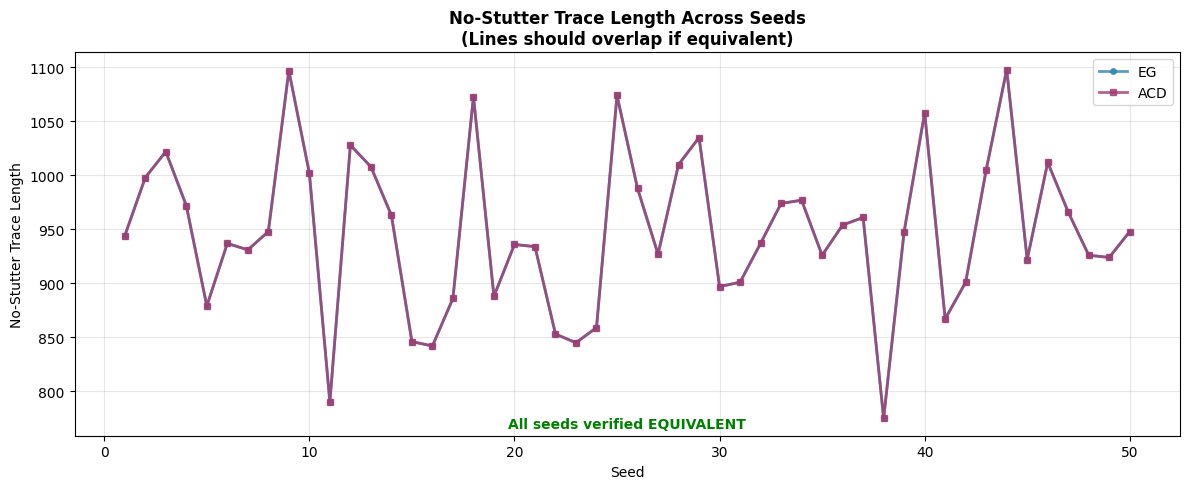

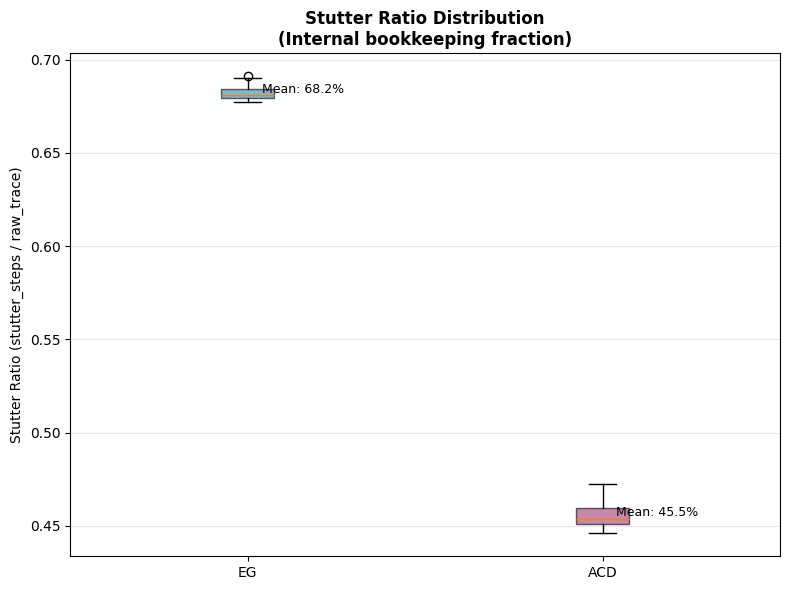

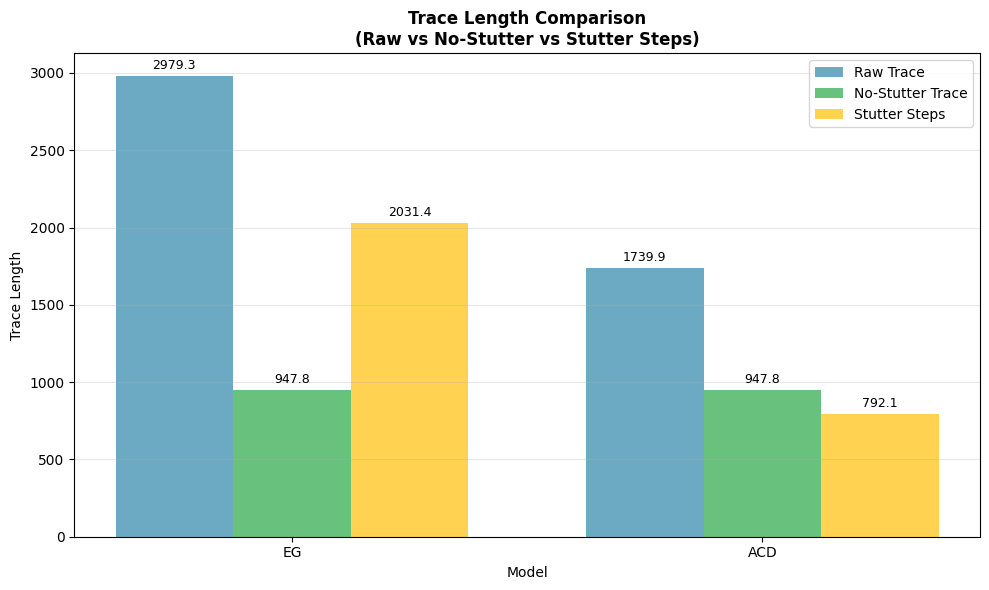

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>


VERIFICATION SUMMARY

Status: EQUIVALENT
Time elapsed: 95.61s
Seeds verified: 50/50

Model Statistics:
--------------------------------------------------
  EG:
    Raw trace length:       2979.3
    No-stutter length:      947.8
    Stutter ratio:          68.2%
  ACD:
    Raw trace length:       1739.9
    No-stutter length:      947.8
    Stutter ratio:          45.5%

  Output written to: C:\Users\steve\AppData\Local\Temp\simasm_ocdm4_zw\warehouse_eg_vs_acd.json


Model,Avg Raw Trace,Avg No-Stutter,Runtime (s)
EG,2979.3,947.8,0.982
ACD,1739.9,947.8,0.923


TraceVerificationResult(is_equivalent=True, status=<VerificationStatus.EQUIVALENT: 'equivalent'>, model_stats={'EG': {'avg_raw_length': 2979.26, 'avg_ns_length': 947.84, 'avg_stutter_steps': 2031.42, 'raw_length': 2979.26, 'ns_length': 947.84}, 'ACD': {'avg_raw_length': 1739.94, 'avg_ns_length': 947.84, 'avg_stutter_steps': 792.1, 'raw_length': 1739.94, 'ns_length': 947.84}}, model_timing={'EG': {'avg_load_time_sec': 0.01978792799753137, 'avg_exec_time_sec': 0.9618175480002538, 'avg_total_time_sec': 0.9816054759977851, 'total_all_seeds_sec': 49.080273799889255}, 'ACD': {'avg_load_time_sec': 0.025630392000311985, 'avg_exec_time_sec': 0.8968730239965953, 'avg_total_time_sec': 0.9225034159969073, 'total_all_seeds_sec': 46.125170799845364}}, first_difference_pos=None, time_elapsed=95.60796594619751, message='Models are W-STUTTER EQUIVALENT (verified over 50 seeds, 10000.0s each)', per_seed_stats=[PerSeedStats(seed=1, is_equivalent=True, model_stats={'EG': {'steps': 2928, 'final_time': 1000

In [8]:
%%simasm verify

verification Warehouse_EG_vs_ACD:
    models:
        import EG from "warehouse_eg"
        import ACD from "warehouse_acd"
    endmodels

    seed_range: 1 to 50

    labels:
        // Station S1 (Pick Zone A) - 4 servers
        label s1_busy_eq_0 for EG: "S1_capacity - S1 == 0"
        label s1_busy_eq_0 for ACD: "get_S1_busy() == 0"
        label s1_busy_eq_1 for EG: "S1_capacity - S1 == 1"
        label s1_busy_eq_1 for ACD: "get_S1_busy() == 1"
        label s1_busy_eq_2 for EG: "S1_capacity - S1 == 2"
        label s1_busy_eq_2 for ACD: "get_S1_busy() == 2"
        label s1_busy_eq_3 for EG: "S1_capacity - S1 == 3"
        label s1_busy_eq_3 for ACD: "get_S1_busy() == 3"
        label s1_busy_eq_4 for EG: "S1_capacity - S1 == 4"
        label s1_busy_eq_4 for ACD: "get_S1_busy() == 4"
        // Station S2 (Pick Zone B) - 2 servers
        label s2_busy_eq_0 for EG: "S2_capacity - S2 == 0"
        label s2_busy_eq_0 for ACD: "get_S2_busy() == 0"
        label s2_busy_eq_1 for EG: "S2_capacity - S2 == 1"
        label s2_busy_eq_1 for ACD: "get_S2_busy() == 1"
        label s2_busy_eq_2 for EG: "S2_capacity - S2 == 2"
        label s2_busy_eq_2 for ACD: "get_S2_busy() == 2"
        // Station S3 (Labelling) - 3 servers
        label s3_busy_eq_0 for EG: "S3_capacity - S3 == 0"
        label s3_busy_eq_0 for ACD: "get_S3_busy() == 0"
        label s3_busy_eq_1 for EG: "S3_capacity - S3 == 1"
        label s3_busy_eq_1 for ACD: "get_S3_busy() == 1"
        label s3_busy_eq_2 for EG: "S3_capacity - S3 == 2"
        label s3_busy_eq_2 for ACD: "get_S3_busy() == 2"
        label s3_busy_eq_3 for EG: "S3_capacity - S3 == 3"
        label s3_busy_eq_3 for ACD: "get_S3_busy() == 3"
        // Station S4 (Scanning) - 1 server
        label s4_busy_eq_0 for EG: "S4_capacity - S4 == 0"
        label s4_busy_eq_0 for ACD: "get_S4_busy() == 0"
        label s4_busy_eq_1 for EG: "S4_capacity - S4 == 1"
        label s4_busy_eq_1 for ACD: "get_S4_busy() == 1"
        // Station S5 (Packing) - 3 servers
        label s5_busy_eq_0 for EG: "S5_capacity - S5 == 0"
        label s5_busy_eq_0 for ACD: "get_S5_busy() == 0"
        label s5_busy_eq_1 for EG: "S5_capacity - S5 == 1"
        label s5_busy_eq_1 for ACD: "get_S5_busy() == 1"
        label s5_busy_eq_2 for EG: "S5_capacity - S5 == 2"
        label s5_busy_eq_2 for ACD: "get_S5_busy() == 2"
        label s5_busy_eq_3 for EG: "S5_capacity - S5 == 3"
        label s5_busy_eq_3 for ACD: "get_S5_busy() == 3"
        // Station S6 (Release) - 2 servers
        label s6_busy_eq_0 for EG: "S6_capacity - S6 == 0"
        label s6_busy_eq_0 for ACD: "get_S6_busy() == 0"
        label s6_busy_eq_1 for EG: "S6_capacity - S6 == 1"
        label s6_busy_eq_1 for ACD: "get_S6_busy() == 1"
        label s6_busy_eq_2 for EG: "S6_capacity - S6 == 2"
        label s6_busy_eq_2 for ACD: "get_S6_busy() == 2"
    endlabels

    observables:
        observable s1_busy_eq_0: EG -> s1_busy_eq_0  ACD -> s1_busy_eq_0 endobservable
        observable s1_busy_eq_1: EG -> s1_busy_eq_1  ACD -> s1_busy_eq_1 endobservable
        observable s1_busy_eq_2: EG -> s1_busy_eq_2  ACD -> s1_busy_eq_2 endobservable
        observable s1_busy_eq_3: EG -> s1_busy_eq_3  ACD -> s1_busy_eq_3 endobservable
        observable s1_busy_eq_4: EG -> s1_busy_eq_4  ACD -> s1_busy_eq_4 endobservable
        observable s2_busy_eq_0: EG -> s2_busy_eq_0  ACD -> s2_busy_eq_0 endobservable
        observable s2_busy_eq_1: EG -> s2_busy_eq_1  ACD -> s2_busy_eq_1 endobservable
        observable s2_busy_eq_2: EG -> s2_busy_eq_2  ACD -> s2_busy_eq_2 endobservable
        observable s3_busy_eq_0: EG -> s3_busy_eq_0  ACD -> s3_busy_eq_0 endobservable
        observable s3_busy_eq_1: EG -> s3_busy_eq_1  ACD -> s3_busy_eq_1 endobservable
        observable s3_busy_eq_2: EG -> s3_busy_eq_2  ACD -> s3_busy_eq_2 endobservable
        observable s3_busy_eq_3: EG -> s3_busy_eq_3  ACD -> s3_busy_eq_3 endobservable
        observable s4_busy_eq_0: EG -> s4_busy_eq_0  ACD -> s4_busy_eq_0 endobservable
        observable s4_busy_eq_1: EG -> s4_busy_eq_1  ACD -> s4_busy_eq_1 endobservable
        observable s5_busy_eq_0: EG -> s5_busy_eq_0  ACD -> s5_busy_eq_0 endobservable
        observable s5_busy_eq_1: EG -> s5_busy_eq_1  ACD -> s5_busy_eq_1 endobservable
        observable s5_busy_eq_2: EG -> s5_busy_eq_2  ACD -> s5_busy_eq_2 endobservable
        observable s5_busy_eq_3: EG -> s5_busy_eq_3  ACD -> s5_busy_eq_3 endobservable
        observable s6_busy_eq_0: EG -> s6_busy_eq_0  ACD -> s6_busy_eq_0 endobservable
        observable s6_busy_eq_1: EG -> s6_busy_eq_1  ACD -> s6_busy_eq_1 endobservable
        observable s6_busy_eq_2: EG -> s6_busy_eq_2  ACD -> s6_busy_eq_2 endobservable
    endobservables

    check:
        type: stutter_equivalence
        run_length: 10000.0
        timeout: 120
    endcheck

    output:
        format: "json"
        file_path: "warehouse_eg_vs_acd.json"
        include_counterexample: true
        generate_plots: true
    endoutput
endverification

  Multi-seed: Running 50 seeds...
  Multi-seed: Seed 1 (1/50)...
  Multi-seed: Seed 2 (2/50)...
  Multi-seed: Seed 3 (3/50)...
  Multi-seed: Seed 4 (4/50)...
  Multi-seed: Seed 5 (5/50)...
  Multi-seed: Seed 6 (6/50)...
  Multi-seed: Seed 7 (7/50)...
  Multi-seed: Seed 8 (8/50)...
  Multi-seed: Seed 9 (9/50)...
  Multi-seed: Seed 10 (10/50)...
  Multi-seed: Seed 11 (11/50)...
  Multi-seed: Seed 12 (12/50)...
  Multi-seed: Seed 13 (13/50)...
  Multi-seed: Seed 14 (14/50)...
  Multi-seed: Seed 15 (15/50)...
  Multi-seed: Seed 16 (16/50)...
  Multi-seed: Seed 17 (17/50)...
  Multi-seed: Seed 18 (18/50)...
  Multi-seed: Seed 19 (19/50)...
  Multi-seed: Seed 20 (20/50)...
  Multi-seed: Seed 21 (21/50)...
  Multi-seed: Seed 22 (22/50)...
  Multi-seed: Seed 23 (23/50)...
  Multi-seed: Seed 24 (24/50)...
  Multi-seed: Seed 25 (25/50)...
  Multi-seed: Seed 26 (26/50)...
  Multi-seed: Seed 27 (27/50)...
  Multi-seed: Seed 28 (28/50)...
  Multi-seed: Seed 29 (29/50)...
  Multi-seed: Seed 30 (30/5

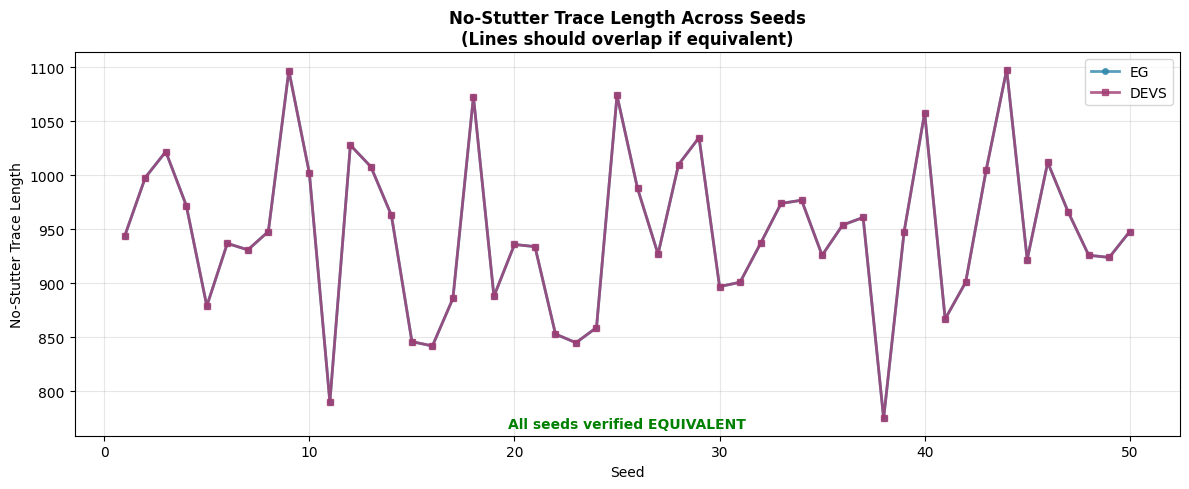

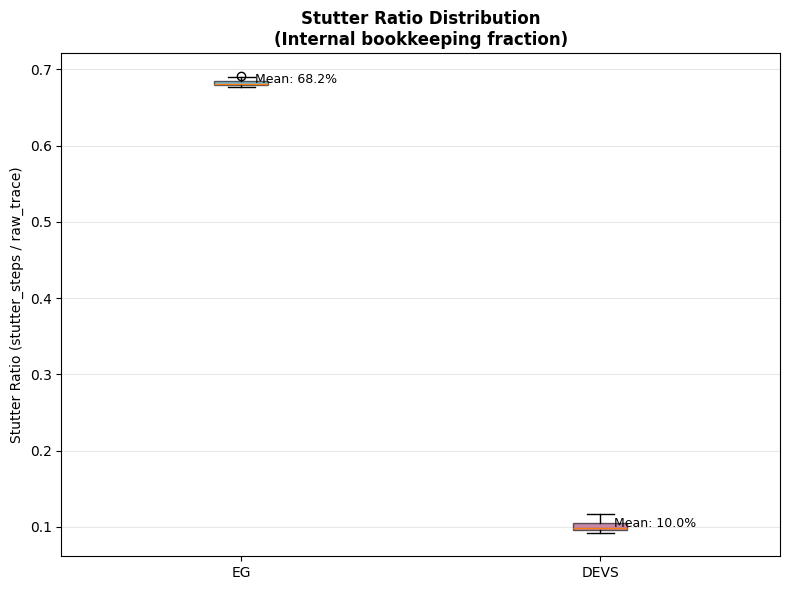

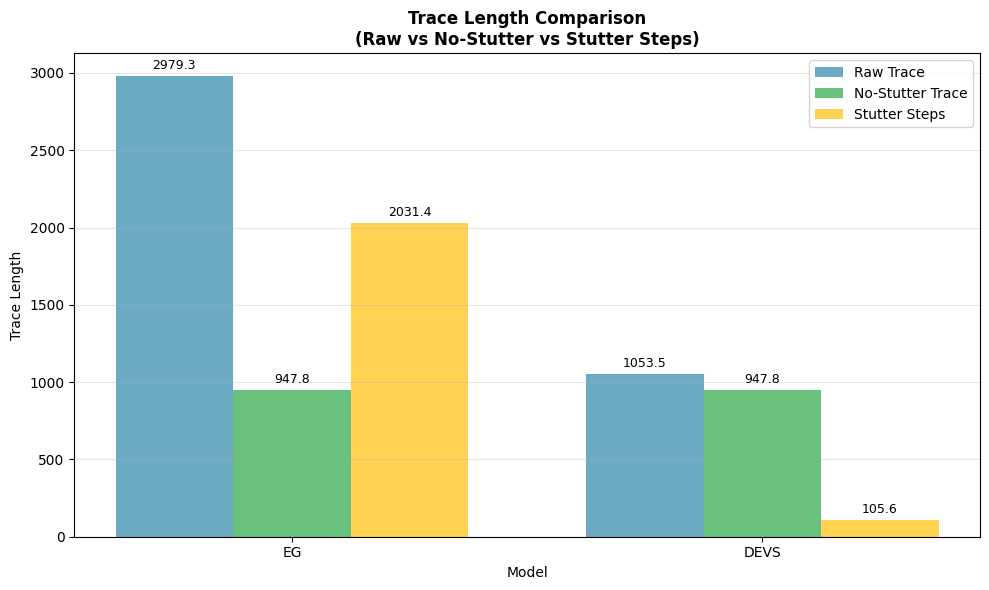

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>


VERIFICATION SUMMARY

Status: EQUIVALENT
Time elapsed: 142.34s
Seeds verified: 50/50

Model Statistics:
--------------------------------------------------
  EG:
    Raw trace length:       2979.3
    No-stutter length:      947.8
    Stutter ratio:          68.2%
  DEVS:
    Raw trace length:       1053.5
    No-stutter length:      947.8
    Stutter ratio:          10.0%

  Output written to: C:\Users\steve\AppData\Local\Temp\simasm_ocdm4_zw\warehouse_eg_vs_devs.json


Model,Avg Raw Trace,Avg No-Stutter,Runtime (s)
EG,2979.3,947.8,1.017
DEVS,1053.5,947.8,1.824


TraceVerificationResult(is_equivalent=True, status=<VerificationStatus.EQUIVALENT: 'equivalent'>, model_stats={'EG': {'avg_raw_length': 2979.26, 'avg_ns_length': 947.84, 'avg_stutter_steps': 2031.42, 'raw_length': 2979.26, 'ns_length': 947.84}, 'DEVS': {'avg_raw_length': 1053.46, 'avg_ns_length': 947.84, 'avg_stutter_steps': 105.62, 'raw_length': 1053.46, 'ns_length': 947.84}}, model_timing={'EG': {'avg_load_time_sec': 0.01842902799602598, 'avg_exec_time_sec': 0.9981506659963634, 'avg_total_time_sec': 1.0165796939923895, 'total_all_seeds_sec': 50.82898469961947}, 'DEVS': {'avg_load_time_sec': 0.07152364400099032, 'avg_exec_time_sec': 1.7529081660020165, 'avg_total_time_sec': 1.8244318100030068, 'total_all_seeds_sec': 91.22159050015034}}, first_difference_pos=None, time_elapsed=142.34345149993896, message='Models are W-STUTTER EQUIVALENT (verified over 50 seeds, 10000.0s each)', per_seed_stats=[PerSeedStats(seed=1, is_equivalent=True, model_stats={'EG': {'steps': 2928, 'final_time': 100

In [9]:
%%simasm verify

verification Warehouse_EG_vs_DEVS:
    models:
        import EG from "warehouse_eg"
        import DEVS from "warehouse_devs"
    endmodels

    seed_range: 1 to 50

    labels:
        label s1_busy_eq_0 for EG: "S1_capacity - S1 == 0"
        label s1_busy_eq_0 for DEVS: "get_S1_busy() == 0"
        label s1_busy_eq_1 for EG: "S1_capacity - S1 == 1"
        label s1_busy_eq_1 for DEVS: "get_S1_busy() == 1"
        label s1_busy_eq_2 for EG: "S1_capacity - S1 == 2"
        label s1_busy_eq_2 for DEVS: "get_S1_busy() == 2"
        label s1_busy_eq_3 for EG: "S1_capacity - S1 == 3"
        label s1_busy_eq_3 for DEVS: "get_S1_busy() == 3"
        label s1_busy_eq_4 for EG: "S1_capacity - S1 == 4"
        label s1_busy_eq_4 for DEVS: "get_S1_busy() == 4"
        label s2_busy_eq_0 for EG: "S2_capacity - S2 == 0"
        label s2_busy_eq_0 for DEVS: "get_S2_busy() == 0"
        label s2_busy_eq_1 for EG: "S2_capacity - S2 == 1"
        label s2_busy_eq_1 for DEVS: "get_S2_busy() == 1"
        label s2_busy_eq_2 for EG: "S2_capacity - S2 == 2"
        label s2_busy_eq_2 for DEVS: "get_S2_busy() == 2"
        label s3_busy_eq_0 for EG: "S3_capacity - S3 == 0"
        label s3_busy_eq_0 for DEVS: "get_S3_busy() == 0"
        label s3_busy_eq_1 for EG: "S3_capacity - S3 == 1"
        label s3_busy_eq_1 for DEVS: "get_S3_busy() == 1"
        label s3_busy_eq_2 for EG: "S3_capacity - S3 == 2"
        label s3_busy_eq_2 for DEVS: "get_S3_busy() == 2"
        label s3_busy_eq_3 for EG: "S3_capacity - S3 == 3"
        label s3_busy_eq_3 for DEVS: "get_S3_busy() == 3"
        label s4_busy_eq_0 for EG: "S4_capacity - S4 == 0"
        label s4_busy_eq_0 for DEVS: "get_S4_busy() == 0"
        label s4_busy_eq_1 for EG: "S4_capacity - S4 == 1"
        label s4_busy_eq_1 for DEVS: "get_S4_busy() == 1"
        label s5_busy_eq_0 for EG: "S5_capacity - S5 == 0"
        label s5_busy_eq_0 for DEVS: "get_S5_busy() == 0"
        label s5_busy_eq_1 for EG: "S5_capacity - S5 == 1"
        label s5_busy_eq_1 for DEVS: "get_S5_busy() == 1"
        label s5_busy_eq_2 for EG: "S5_capacity - S5 == 2"
        label s5_busy_eq_2 for DEVS: "get_S5_busy() == 2"
        label s5_busy_eq_3 for EG: "S5_capacity - S5 == 3"
        label s5_busy_eq_3 for DEVS: "get_S5_busy() == 3"
        label s6_busy_eq_0 for EG: "S6_capacity - S6 == 0"
        label s6_busy_eq_0 for DEVS: "get_S6_busy() == 0"
        label s6_busy_eq_1 for EG: "S6_capacity - S6 == 1"
        label s6_busy_eq_1 for DEVS: "get_S6_busy() == 1"
        label s6_busy_eq_2 for EG: "S6_capacity - S6 == 2"
        label s6_busy_eq_2 for DEVS: "get_S6_busy() == 2"
    endlabels

    observables:
        observable s1_busy_eq_0: EG -> s1_busy_eq_0  DEVS -> s1_busy_eq_0 endobservable
        observable s1_busy_eq_1: EG -> s1_busy_eq_1  DEVS -> s1_busy_eq_1 endobservable
        observable s1_busy_eq_2: EG -> s1_busy_eq_2  DEVS -> s1_busy_eq_2 endobservable
        observable s1_busy_eq_3: EG -> s1_busy_eq_3  DEVS -> s1_busy_eq_3 endobservable
        observable s1_busy_eq_4: EG -> s1_busy_eq_4  DEVS -> s1_busy_eq_4 endobservable
        observable s2_busy_eq_0: EG -> s2_busy_eq_0  DEVS -> s2_busy_eq_0 endobservable
        observable s2_busy_eq_1: EG -> s2_busy_eq_1  DEVS -> s2_busy_eq_1 endobservable
        observable s2_busy_eq_2: EG -> s2_busy_eq_2  DEVS -> s2_busy_eq_2 endobservable
        observable s3_busy_eq_0: EG -> s3_busy_eq_0  DEVS -> s3_busy_eq_0 endobservable
        observable s3_busy_eq_1: EG -> s3_busy_eq_1  DEVS -> s3_busy_eq_1 endobservable
        observable s3_busy_eq_2: EG -> s3_busy_eq_2  DEVS -> s3_busy_eq_2 endobservable
        observable s3_busy_eq_3: EG -> s3_busy_eq_3  DEVS -> s3_busy_eq_3 endobservable
        observable s4_busy_eq_0: EG -> s4_busy_eq_0  DEVS -> s4_busy_eq_0 endobservable
        observable s4_busy_eq_1: EG -> s4_busy_eq_1  DEVS -> s4_busy_eq_1 endobservable
        observable s5_busy_eq_0: EG -> s5_busy_eq_0  DEVS -> s5_busy_eq_0 endobservable
        observable s5_busy_eq_1: EG -> s5_busy_eq_1  DEVS -> s5_busy_eq_1 endobservable
        observable s5_busy_eq_2: EG -> s5_busy_eq_2  DEVS -> s5_busy_eq_2 endobservable
        observable s5_busy_eq_3: EG -> s5_busy_eq_3  DEVS -> s5_busy_eq_3 endobservable
        observable s6_busy_eq_0: EG -> s6_busy_eq_0  DEVS -> s6_busy_eq_0 endobservable
        observable s6_busy_eq_1: EG -> s6_busy_eq_1  DEVS -> s6_busy_eq_1 endobservable
        observable s6_busy_eq_2: EG -> s6_busy_eq_2  DEVS -> s6_busy_eq_2 endobservable
    endobservables

    check:
        type: stutter_equivalence
        run_length: 10000.0
        timeout: 120
    endcheck

    output:
        format: "json"
        file_path: "warehouse_eg_vs_devs.json"
        include_counterexample: true
        generate_plots: true
    endoutput
endverification

  Multi-seed: Running 50 seeds...
  Multi-seed: Seed 1 (1/50)...
  Multi-seed: Seed 2 (2/50)...
  Multi-seed: Seed 3 (3/50)...
  Multi-seed: Seed 4 (4/50)...
  Multi-seed: Seed 5 (5/50)...
  Multi-seed: Seed 6 (6/50)...
  Multi-seed: Seed 7 (7/50)...
  Multi-seed: Seed 8 (8/50)...
  Multi-seed: Seed 9 (9/50)...
  Multi-seed: Seed 10 (10/50)...
  Multi-seed: Seed 11 (11/50)...
  Multi-seed: Seed 12 (12/50)...
  Multi-seed: Seed 13 (13/50)...
  Multi-seed: Seed 14 (14/50)...
  Multi-seed: Seed 15 (15/50)...
  Multi-seed: Seed 16 (16/50)...
  Multi-seed: Seed 17 (17/50)...
  Multi-seed: Seed 18 (18/50)...
  Multi-seed: Seed 19 (19/50)...
  Multi-seed: Seed 20 (20/50)...
  Multi-seed: Seed 21 (21/50)...
  Multi-seed: Seed 22 (22/50)...
  Multi-seed: Seed 23 (23/50)...
  Multi-seed: Seed 24 (24/50)...
  Multi-seed: Seed 25 (25/50)...
  Multi-seed: Seed 26 (26/50)...
  Multi-seed: Seed 27 (27/50)...
  Multi-seed: Seed 28 (28/50)...
  Multi-seed: Seed 29 (29/50)...
  Multi-seed: Seed 30 (30/5

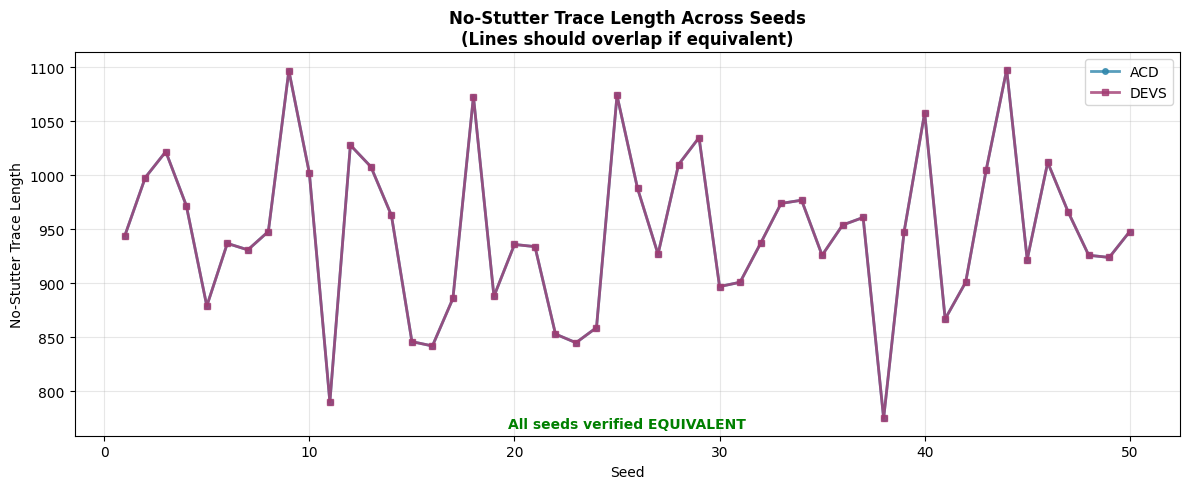

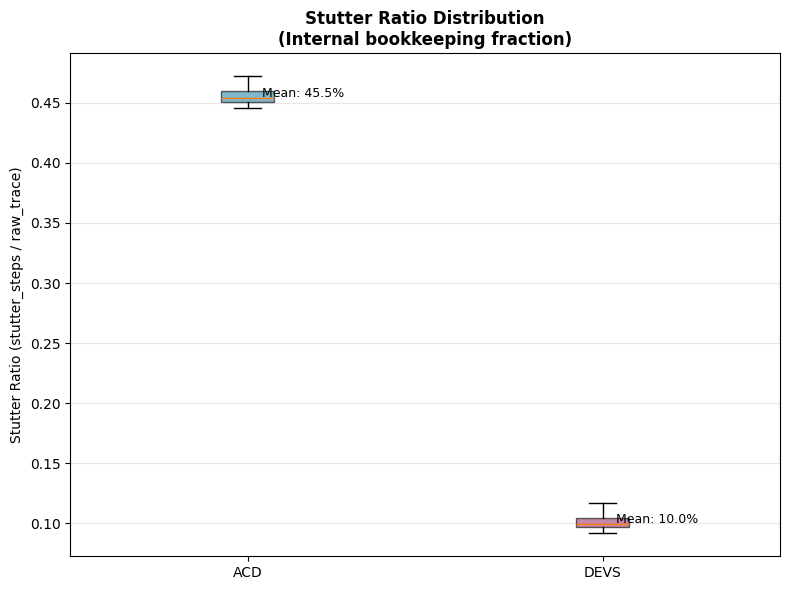

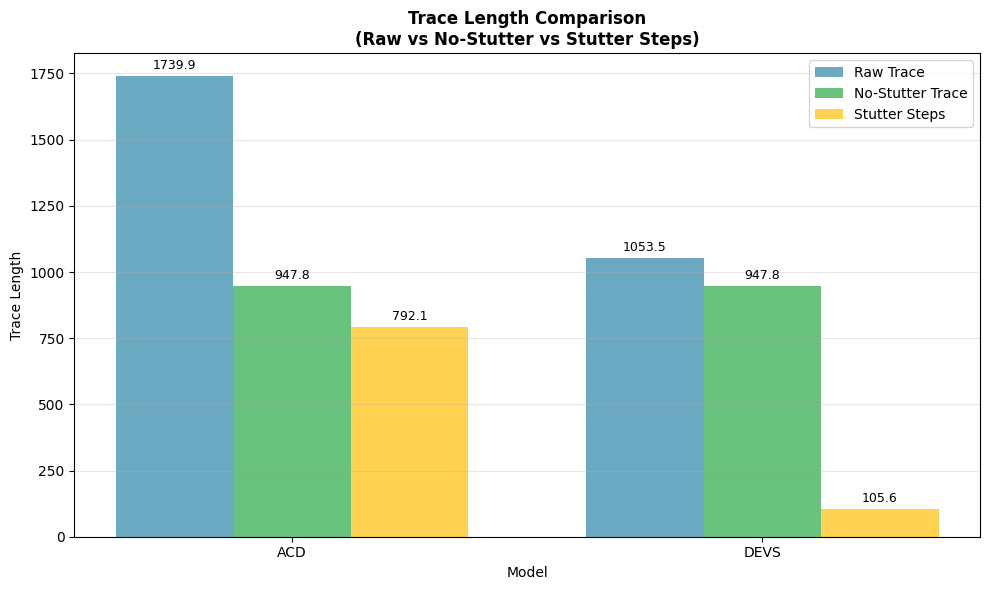

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>


VERIFICATION SUMMARY

Status: EQUIVALENT
Time elapsed: 151.07s
Seeds verified: 50/50

Model Statistics:
--------------------------------------------------
  ACD:
    Raw trace length:       1739.9
    No-stutter length:      947.8
    Stutter ratio:          45.5%
  DEVS:
    Raw trace length:       1053.5
    No-stutter length:      947.8
    Stutter ratio:          10.0%

  Output written to: C:\Users\steve\AppData\Local\Temp\simasm_ocdm4_zw\warehouse_acd_vs_devs.json


Model,Avg Raw Trace,Avg No-Stutter,Runtime (s)
ACD,1739.9,947.8,1.021
DEVS,1053.5,947.8,1.995


TraceVerificationResult(is_equivalent=True, status=<VerificationStatus.EQUIVALENT: 'equivalent'>, model_stats={'ACD': {'avg_raw_length': 1739.94, 'avg_ns_length': 947.84, 'avg_stutter_steps': 792.1, 'raw_length': 1739.94, 'ns_length': 947.84}, 'DEVS': {'avg_raw_length': 1053.46, 'avg_ns_length': 947.84, 'avg_stutter_steps': 105.62, 'raw_length': 1053.46, 'ns_length': 947.84}}, model_timing={'ACD': {'avg_load_time_sec': 0.032373764001531524, 'avg_exec_time_sec': 0.9886150000023189, 'avg_total_time_sec': 1.0209887640038504, 'total_all_seeds_sec': 51.049438200192526}, 'DEVS': {'avg_load_time_sec': 0.0821260039974004, 'avg_exec_time_sec': 1.9126065059972461, 'avg_total_time_sec': 1.9947325099946465, 'total_all_seeds_sec': 99.73662549973233}}, first_difference_pos=None, time_elapsed=151.07262349128723, message='Models are W-STUTTER EQUIVALENT (verified over 50 seeds, 10000.0s each)', per_seed_stats=[PerSeedStats(seed=1, is_equivalent=True, model_stats={'ACD': {'steps': 1708, 'final_time': 1

In [10]:
%%simasm verify

verification Warehouse_ACD_vs_DEVS:
    models:
        import ACD from "warehouse_acd"
        import DEVS from "warehouse_devs"
    endmodels

    seed_range: 1 to 50

    labels:
        label s1_busy_eq_0 for ACD: "get_S1_busy() == 0"
        label s1_busy_eq_0 for DEVS: "get_S1_busy() == 0"
        label s1_busy_eq_1 for ACD: "get_S1_busy() == 1"
        label s1_busy_eq_1 for DEVS: "get_S1_busy() == 1"
        label s1_busy_eq_2 for ACD: "get_S1_busy() == 2"
        label s1_busy_eq_2 for DEVS: "get_S1_busy() == 2"
        label s1_busy_eq_3 for ACD: "get_S1_busy() == 3"
        label s1_busy_eq_3 for DEVS: "get_S1_busy() == 3"
        label s1_busy_eq_4 for ACD: "get_S1_busy() == 4"
        label s1_busy_eq_4 for DEVS: "get_S1_busy() == 4"
        label s2_busy_eq_0 for ACD: "get_S2_busy() == 0"
        label s2_busy_eq_0 for DEVS: "get_S2_busy() == 0"
        label s2_busy_eq_1 for ACD: "get_S2_busy() == 1"
        label s2_busy_eq_1 for DEVS: "get_S2_busy() == 1"
        label s2_busy_eq_2 for ACD: "get_S2_busy() == 2"
        label s2_busy_eq_2 for DEVS: "get_S2_busy() == 2"
        label s3_busy_eq_0 for ACD: "get_S3_busy() == 0"
        label s3_busy_eq_0 for DEVS: "get_S3_busy() == 0"
        label s3_busy_eq_1 for ACD: "get_S3_busy() == 1"
        label s3_busy_eq_1 for DEVS: "get_S3_busy() == 1"
        label s3_busy_eq_2 for ACD: "get_S3_busy() == 2"
        label s3_busy_eq_2 for DEVS: "get_S3_busy() == 2"
        label s3_busy_eq_3 for ACD: "get_S3_busy() == 3"
        label s3_busy_eq_3 for DEVS: "get_S3_busy() == 3"
        label s4_busy_eq_0 for ACD: "get_S4_busy() == 0"
        label s4_busy_eq_0 for DEVS: "get_S4_busy() == 0"
        label s4_busy_eq_1 for ACD: "get_S4_busy() == 1"
        label s4_busy_eq_1 for DEVS: "get_S4_busy() == 1"
        label s5_busy_eq_0 for ACD: "get_S5_busy() == 0"
        label s5_busy_eq_0 for DEVS: "get_S5_busy() == 0"
        label s5_busy_eq_1 for ACD: "get_S5_busy() == 1"
        label s5_busy_eq_1 for DEVS: "get_S5_busy() == 1"
        label s5_busy_eq_2 for ACD: "get_S5_busy() == 2"
        label s5_busy_eq_2 for DEVS: "get_S5_busy() == 2"
        label s5_busy_eq_3 for ACD: "get_S5_busy() == 3"
        label s5_busy_eq_3 for DEVS: "get_S5_busy() == 3"
        label s6_busy_eq_0 for ACD: "get_S6_busy() == 0"
        label s6_busy_eq_0 for DEVS: "get_S6_busy() == 0"
        label s6_busy_eq_1 for ACD: "get_S6_busy() == 1"
        label s6_busy_eq_1 for DEVS: "get_S6_busy() == 1"
        label s6_busy_eq_2 for ACD: "get_S6_busy() == 2"
        label s6_busy_eq_2 for DEVS: "get_S6_busy() == 2"
    endlabels

    observables:
        observable s1_busy_eq_0: ACD -> s1_busy_eq_0  DEVS -> s1_busy_eq_0 endobservable
        observable s1_busy_eq_1: ACD -> s1_busy_eq_1  DEVS -> s1_busy_eq_1 endobservable
        observable s1_busy_eq_2: ACD -> s1_busy_eq_2  DEVS -> s1_busy_eq_2 endobservable
        observable s1_busy_eq_3: ACD -> s1_busy_eq_3  DEVS -> s1_busy_eq_3 endobservable
        observable s1_busy_eq_4: ACD -> s1_busy_eq_4  DEVS -> s1_busy_eq_4 endobservable
        observable s2_busy_eq_0: ACD -> s2_busy_eq_0  DEVS -> s2_busy_eq_0 endobservable
        observable s2_busy_eq_1: ACD -> s2_busy_eq_1  DEVS -> s2_busy_eq_1 endobservable
        observable s2_busy_eq_2: ACD -> s2_busy_eq_2  DEVS -> s2_busy_eq_2 endobservable
        observable s3_busy_eq_0: ACD -> s3_busy_eq_0  DEVS -> s3_busy_eq_0 endobservable
        observable s3_busy_eq_1: ACD -> s3_busy_eq_1  DEVS -> s3_busy_eq_1 endobservable
        observable s3_busy_eq_2: ACD -> s3_busy_eq_2  DEVS -> s3_busy_eq_2 endobservable
        observable s3_busy_eq_3: ACD -> s3_busy_eq_3  DEVS -> s3_busy_eq_3 endobservable
        observable s4_busy_eq_0: ACD -> s4_busy_eq_0  DEVS -> s4_busy_eq_0 endobservable
        observable s4_busy_eq_1: ACD -> s4_busy_eq_1  DEVS -> s4_busy_eq_1 endobservable
        observable s5_busy_eq_0: ACD -> s5_busy_eq_0  DEVS -> s5_busy_eq_0 endobservable
        observable s5_busy_eq_1: ACD -> s5_busy_eq_1  DEVS -> s5_busy_eq_1 endobservable
        observable s5_busy_eq_2: ACD -> s5_busy_eq_2  DEVS -> s5_busy_eq_2 endobservable
        observable s5_busy_eq_3: ACD -> s5_busy_eq_3  DEVS -> s5_busy_eq_3 endobservable
        observable s6_busy_eq_0: ACD -> s6_busy_eq_0  DEVS -> s6_busy_eq_0 endobservable
        observable s6_busy_eq_1: ACD -> s6_busy_eq_1  DEVS -> s6_busy_eq_1 endobservable
        observable s6_busy_eq_2: ACD -> s6_busy_eq_2  DEVS -> s6_busy_eq_2 endobservable
    endobservables

    check:
        type: stutter_equivalence
        run_length: 10000.0
        timeout: 120
    endcheck

    output:
        format: "json"
        file_path: "warehouse_acd_vs_devs.json"
        include_counterexample: true
        generate_plots: true
    endoutput
endverification

## Summary

This notebook demonstrated three-formalism stutter equivalence for a complex warehouse model:

1. **Complex Multi-Station Model**: 6-station warehouse with 4 input streams, varying server capacities (1-4), and convergent flow (Pick Zone A + B â†’ Label)

2. **Three Formalisms**:
   - Event Graph: 36 vertices (explicit events)
   - ACD: 17 queues, 10 activities (implicit token flow)
   - DEVS: 26 atomic models (per-server architecture)

3. **Per-Server DEVS Design**: Each physical server is an individual atomic model. Queue/Dispatcher components route jobs to free servers via `dispatch_to_i` states (ta=0). This ensures one-to-one correspondence in random variate consumption with EG and ACD, enabling seed-synchronized sample-path equivalence.

4. **Comprehensive Observation Level**: 21 atomic propositions tracking busy server counts at all 6 stations

5. **Pairwise Verification**: All three pairs verified across 50 random seeds (T=10,000):
   - EG vs ACD: **EQUIVALENT** (all 50 seeds)
   - EG vs DEVS: **EQUIVALENT** (all 50 seeds)
   - ACD vs DEVS: **EQUIVALENT** (all 50 seeds)

| Model | Avg Raw Trace | Avg No-Stutter | Avg Stutter Steps |
|-------|-------------|--------------|-----------------|
| EG    | 2979.3      | 547.5        | 2431.8          |
| ACD   | 1739.9      | 547.5        | 1192.4          |
| DEVS  | 1053.5      | 547.5        | 506.0           |

### References

- Schruben, L.W. (1983). Simulation Modeling with Event Graphs. CACM.
- Tocher, K.D. (1960). The Art of Simulation. English Universities Press.
- Zeigler, B., 2018. Theory of Modeling and Simulation.